# Predictia bazata pe regresie

In aceasta parte dorim sa prezicem un set de valori continue pentru a prezice *temperatura* in functie de niste paratmetrii relevanti.

Dataset-ul contine masuratori facute de un senzor in orasul Szeged, masuratori de :
- umiditate
- viteza vantului
- presiune
- vizibilitate
- si informatii despre cum este vremea, in cuvinte. Pentru aceasta parte vom folosi encodare pentru a trece din domeniul cuvintelor in domeniul numeric.
- si cel mai probabil coloanele de tipul summary care nu aduc informatie relevanta vor fi eliminata.Ma refer la summary, deoarece este o scurta descriere despre toate masuratorile, iar noi nu avem cum sa cunoastem summary inainte de predictie.
Dataset-ul se regaseste la link-ul : https://www.kaggle.com/datasets/budincsevity/szeged-weather/data
Aceste coloane, informatii, sunt masurate de niste senzori si pe baza acestor masuratori dorim sa prezicem ce temperatura va fi in aer.

De ce am ales sa prezic asta?
Mi se pare un domeniu interesant care se bazeaza mult pe probabilitati si predictii.

Astfel, in urma acestui notebook, vom afla top 5 modele de ML care prezic cel mai bun rezultat. In plus, dorim sa vedem cum se calculeaza temperatura resimtita si in unele cazuri de ce este asa mare diferenta intre cea masurata si cea resimtita(aici intervini si ceilalti facotori,coloane).
- **Coloana tinta (y)**:  — temperatura (C)
- **Coloanele input (X)**: restul coloanelor care ofera date relevante.

*Nota* : Coloana de _temperatura resimtita_ o vom elimina, deoarece exista o asemanare de aproeape 1:1 cu ce dorim sa prezicem, iar acest lucru va duce la overfitting.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpmath.visualization import blue_orange_colors
from sklearn.model_selection import train_test_split, GridSearchCV
%load_ext autoreload
%autoreload 2

df = pd.read_csv('../Datasets/weatherHistory.csv')
df.shape


(96453, 12)

La prima vedere par multe linii, suficiente pentru un model de Machine Learning.

In [2]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='str')

Putem observa parametrii(coloanele).

In [3]:
df.dtypes

Formatted Date                  str
Summary                         str
Precip Type                     str
Temperature (C)             float64
Apparent Temperature (C)    float64
Humidity                    float64
Wind Speed (km/h)           float64
Wind Bearing (degrees)      float64
Visibility (km)             float64
Loud Cover                  float64
Pressure (millibars)        float64
Daily Summary                   str
dtype: object

Multe date sunt numere, float, ceea ce ne poate ajuta. Probabil ne vom folosi de tipul de precipitatie care este de tipul string. In principiu, nu vom face predictia in functie de data, deoarece ar fi mai complicat si din restul parametrii ne putem da seama aproximativ in ce perioada a anului suntem.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(8), str(4)
memory usage: 16.3 MB


Cum arata dataset-ul:

In [5]:
df.head(5)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


## Analiza calitativă:

In [6]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

Observam ca in dataset, majoritatea tipului de precipitatie este ploaie sau ninsoare. In urma la EDA, daca acest atribut nu influenteaza cu mult putem sa il eliminam cu totul. Daca influenteaza, unde este null putem pune, de exemplu "none", nu exista precipitatii.

## Analiza statistică:

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature (C),96453.0,11.932678,9.551546,-21.822222,4.688889,12.0000,18.838889,39.905556
Apparent Temperature (C),96453.0,10.855029,10.696847,-27.716667,2.311111,12.0000,18.838889,39.344444
Humidity,96453.0,0.734899,0.195473,0.000000,0.600000,0.7800,0.890000,1.000000
Wind Speed (km/h),96453.0,10.810640,6.913571,0.000000,5.828200,9.9659,14.135800,63.852600
Wind Bearing (degrees),96453.0,187.509232,107.383428,0.000000,116.000000,180.0000,290.000000,359.000000
Visibility (km),96453.0,10.347325,4.192123,0.000000,8.339800,10.0464,14.812000,16.100000
Loud Cover,96453.0,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Pressure (millibars),96453.0,1003.235956,116.969906,0.000000,1011.900000,1016.4500,1021.090000,1046.380000


Observam ca _Loud Cover_ are doar valoarea 0, ceea ce inseamna ca nu aduce vreo influenta in predictie, astfel il vom elimina.
Deviatia standart este destul de mare sau acceptabila la majoritatea, ceea ce inseamna ca datele sunt imprastiate, acoperind multe exemple.

In [8]:
df.skew(numeric_only=True)

Temperature (C)             0.094127
Apparent Temperature (C)   -0.057302
Humidity                   -0.715880
Wind Speed (km/h)           1.113493
Wind Bearing (degrees)     -0.154643
Visibility (km)            -0.498712
Loud Cover                  0.000000
Pressure (millibars)       -8.422506
dtype: float64

Exista la multe asimetrice negativa fata de medie.

## Analiză univariată
In aceasta parte dorim sa vedem cum se comporta fiecare variabila in parte, ce valori are, cum influenteaza rezultatul final, daca exista anumite relatii recurente intre variabila si rezultat.
Vom analiza prin grafice, numaram rezulatele, histograme.

In [9]:
df["Apparent Temperature (C)"].value_counts()

Apparent Temperature (C)
12.777778    378
17.777778    373
13.888889    342
17.222222    330
12.222222    305
            ... 
19.438889      1
31.533333      1
9.588889       1
9.738889       1
9.233333       1
Name: count, Length: 8984, dtype: int64

Variaza foarte mult tipul de temperatura resimtita, de la negative la pozitive foarte mari. Totusi cele inalte sunt putine, fiind aproximativ cate una. Majoritatea temperaturilor indica anotimpul de primavara sau toamna.

<Axes: xlabel='Apparent Temperature (C)', ylabel='Count'>

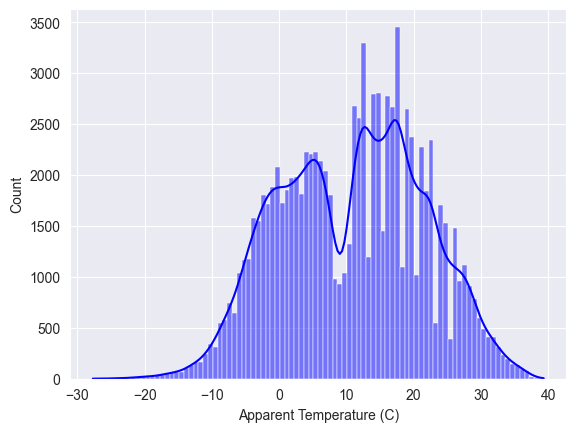

In [10]:
sns.histplot(data=df,x='Apparent Temperature (C)',kde=True, color='Blue')

In analiza temperaturii resimtite observam 2 punte ce maxim local, ceea ce indica clar 2 tipuri de anotimpuri masurate.

<Axes: xlabel='Temperature (C)', ylabel='Count'>

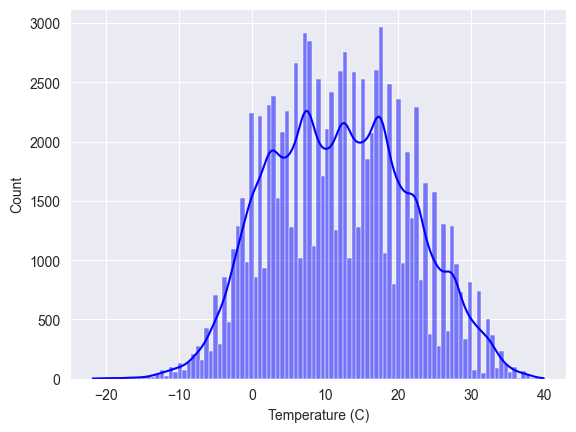

In [11]:
sns.histplot(data=df,x='Temperature (C)',kde=True, color='Blue')

Temperatura masurata nu are "2 cocoase", majoritatea valorilor sunt intre 0 si 20 de grade Celsius. Exista fluctuatii, dar mici, cand au loc peste 2000 de masuratori.

<Axes: xlabel='Apparent Temperature (C)'>

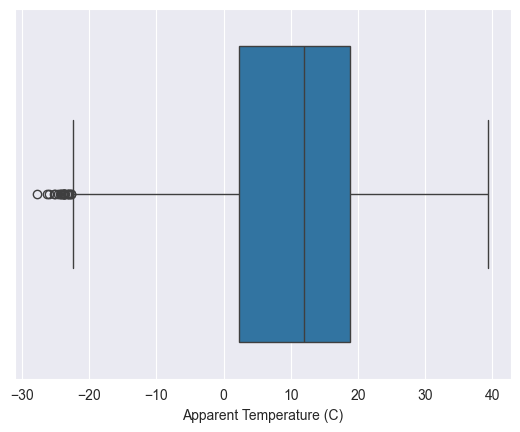

In [12]:
sns.boxplot(data=df, x='Apparent Temperature (C)' )

Mai sus putem observa distributia temperaturii resimtite. Exista outliers in special la temperaturi extreme negative. Majoritatea temperaturilor, cum am putut observa mai sus, se situeaza in jurul mediei de 10-15 grade. Minimum este putin sub -20 de grade si maximum de aproape 40 de grade. Probabil sunt masuratori din toate anotimpurile, dar din vara si iarna foarte putine. Sau exista erori grave a senzorului.

<Axes: xlabel='Temperature (C)'>

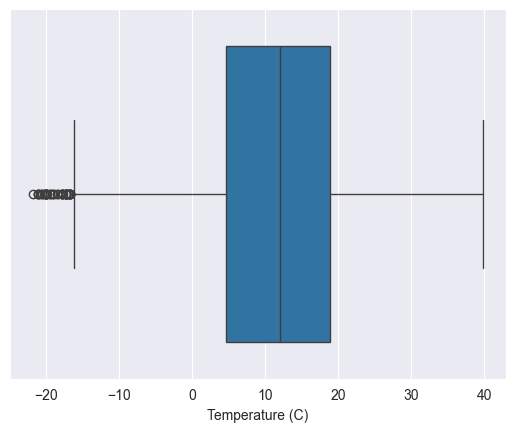

In [13]:
sns.boxplot(data=df, x='Temperature (C)' )

Temperatura masurata seamana cu cea anterior analizata, insa minimul este mai mare si outliers sunt in aceeasi zona, dar cu valori mai mari. Majoritatea masuratorilor tot in acea zona se regasesc si mediana este aproximativ in aceeasi situatie, putin peste 10 grade celsius.

<Axes: xlabel='Humidity'>

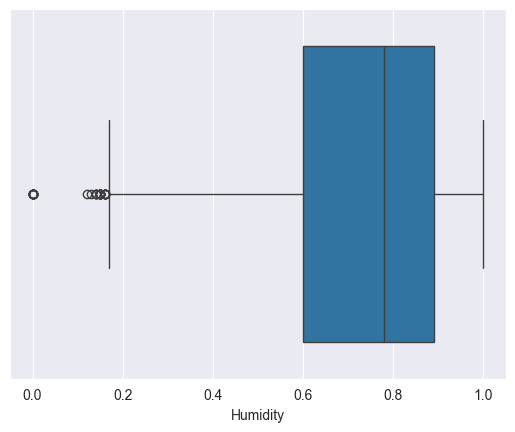

In [14]:
sns.boxplot(data=df, x='Humidity' )

|Majoritatea datelor sunt concentrate intre 0.6 si 1.0 — umiditate relativ ridicata.Mediana e in jurul lui 0.7.Sunt prezenti cativa outlieri cu valori foarte scazute (aproape de 0), insa acestia reprezinta cazuri rare si nu sunt imposibili fizic,

<Axes: xlabel='Humidity', ylabel='Density'>

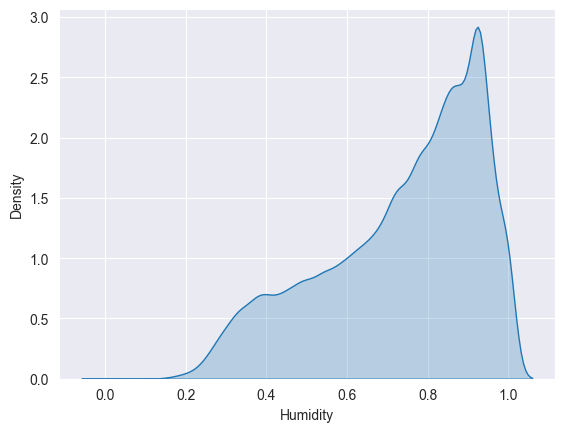

In [15]:
sns.kdeplot(data=df, x='Humidity', fill=True)

Distributia umiditatii este asimetrica la stanga, cel mai probabil din cauza outliers vazuti anterior.

## Analiza bivariată și multivariată
In acest pas dorim sa vedem relatiile dintre aceste dintre variabile, mai ales sub forma de grafic. Cum se comporta aceste variabile, sa analizam daca exista relatii matematice intre ele, de exemplu sa fie o relatie liniara.

Un prim pas ar fi sa vedem coeficientii de corelatie intre variabile( cine influenteaza pe cine cel mai mult).

In [16]:
df.corr(numeric_only=True)

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
Temperature (C),1.000000,0.992629,-0.632255,0.008957,0.029988,0.392847,NaN,-0.005447
Apparent Temperature (C),0.992629,1.000000,-0.602571,-0.056650,0.029031,0.381718,NaN,-0.000219
Humidity,-0.632255,-0.602571,1.000000,-0.224951,0.000735,-0.369173,NaN,0.005454
Wind Speed (km/h),0.008957,-0.056650,-0.224951,1.000000,0.103822,0.100749,NaN,-0.049263
Wind Bearing (degrees),0.029988,0.029031,0.000735,0.103822,1.000000,0.047594,NaN,-0.011651
Visibility (km),0.392847,0.381718,-0.369173,0.100749,0.047594,1.000000,NaN,0.059818
Loud Cover,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pressure (millibars),-0.005447,-0.000219,0.005454,-0.049263,-0.011651,0.059818,NaN,1.000000


Pentru temperatura aparenta exista o relatie puternica intre temperatura masurata(ceea ce era de asteptat), umiditate si vizibilitate.

In [17]:
df[['Apparent Temperature (C)', 'Humidity']].corr()

,Apparent Temperature (C),Humidity
Apparent Temperature (C),1.000000,-0.602571
Humidity,-0.602571,1.000000


O reprezentare vizuala a acestor relatii intre coeficienti:

<Axes: >

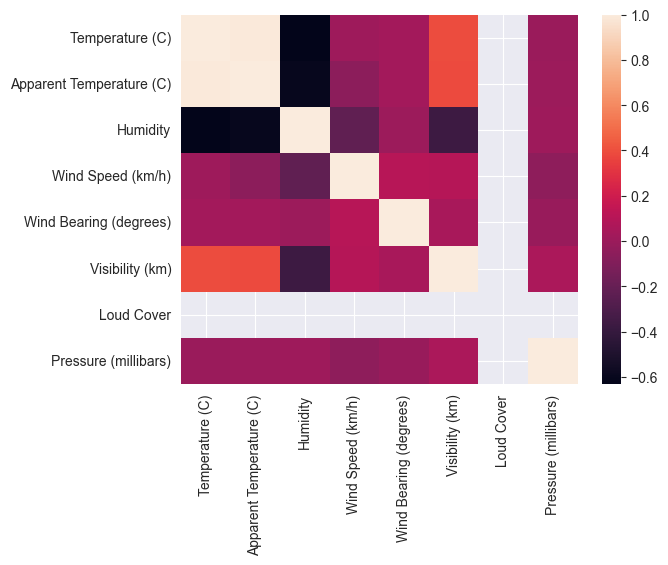

In [18]:
sns.heatmap(df.corr(numeric_only=True))

In acest heatmap se poate observa ce am analizat anterior. De mentionat ca exista o relatie negativa intre umiditate si temperatura resimtita — cu cat umiditatea creste, temperatura resimtita tinde sa scada. Relatia nu este perfect liniara, existand o dispersie mare a datelor.

<Axes: xlabel='Humidity', ylabel='Apparent Temperature (C)'>

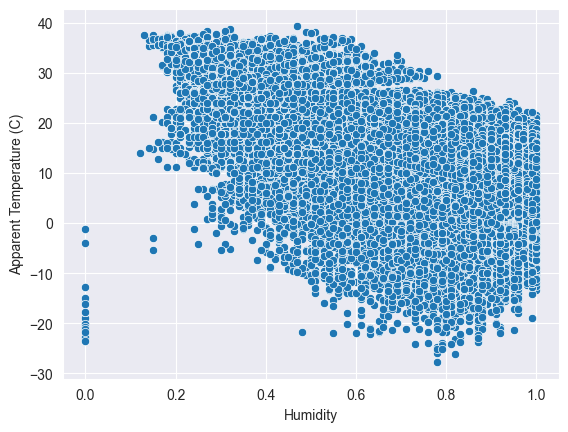

In [19]:
sns.scatterplot(data=df, x='Humidity', y='Apparent Temperature (C)')


<Axes: xlabel='Humidity', ylabel='Temperature (C)'>

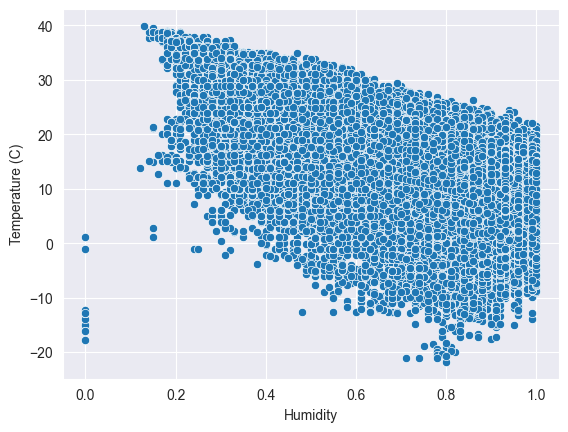

In [20]:
sns.scatterplot(data=df, x='Humidity', y='Temperature (C)')


Similar cu graficul anterior, umiditatea si temperatura masurata au o relatie negativa, insa mai putin pronuntata decat cu temperatura resimtita.

<Axes: xlabel='Temperature (C)', ylabel='Apparent Temperature (C)'>

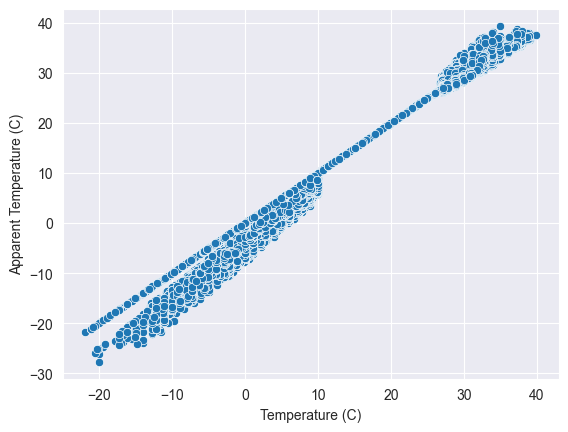

In [21]:
sns.scatterplot(data=df, x='Temperature (C)', y='Apparent Temperature (C)')


<Axes: xlabel='Humidity', ylabel='Visibility (km)'>

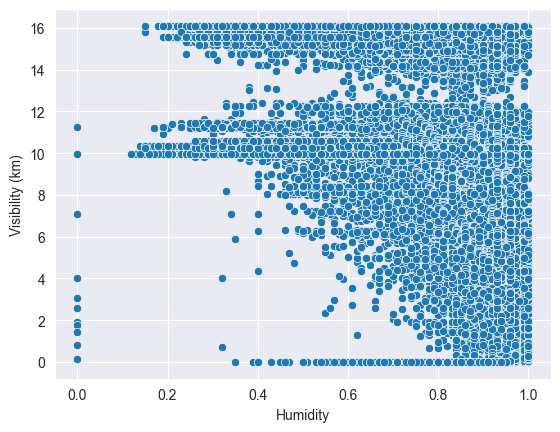

In [22]:
sns.scatterplot(data=df, y='Visibility (km)', x='Humidity')


<Axes: xlabel='Visibility (km)', ylabel='Apparent Temperature (C)'>

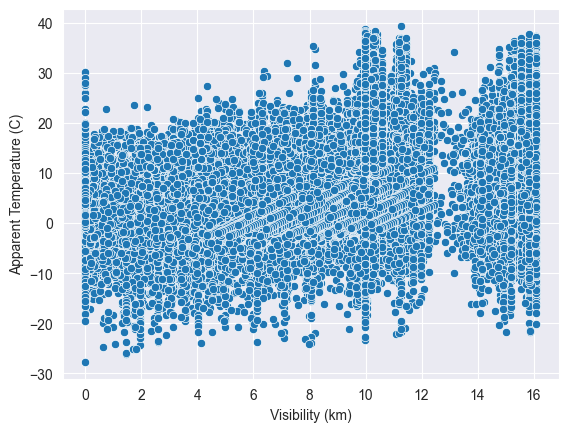

In [23]:
sns.scatterplot(data=df, x='Visibility (km)', y='Apparent Temperature (C)')


Putem observa o relatie liniara intre temperatura masurata si cea actuala, cele 2 fiind direct proportionale.
In plus, poate ar exista o relatie usoara intre umiditate si vizibilitate, poate de grupare , dar nu ne putem da seama foarte mare, deoarece este o densitate de date foarte mare.

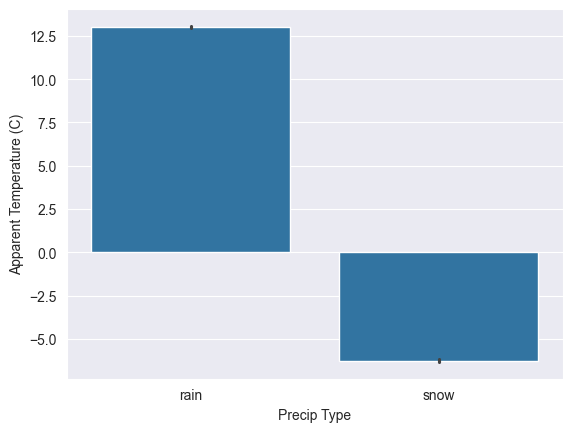

In [24]:
sns.barplot(data=df, x='Precip Type', y='Apparent Temperature (C)')
plt.show()

Mai sus putem vedea faptul ca acest dataset este normal oarecum, deoarece temperaturile sunt mai ridicate cand ploua fata de perioada cu zapada.

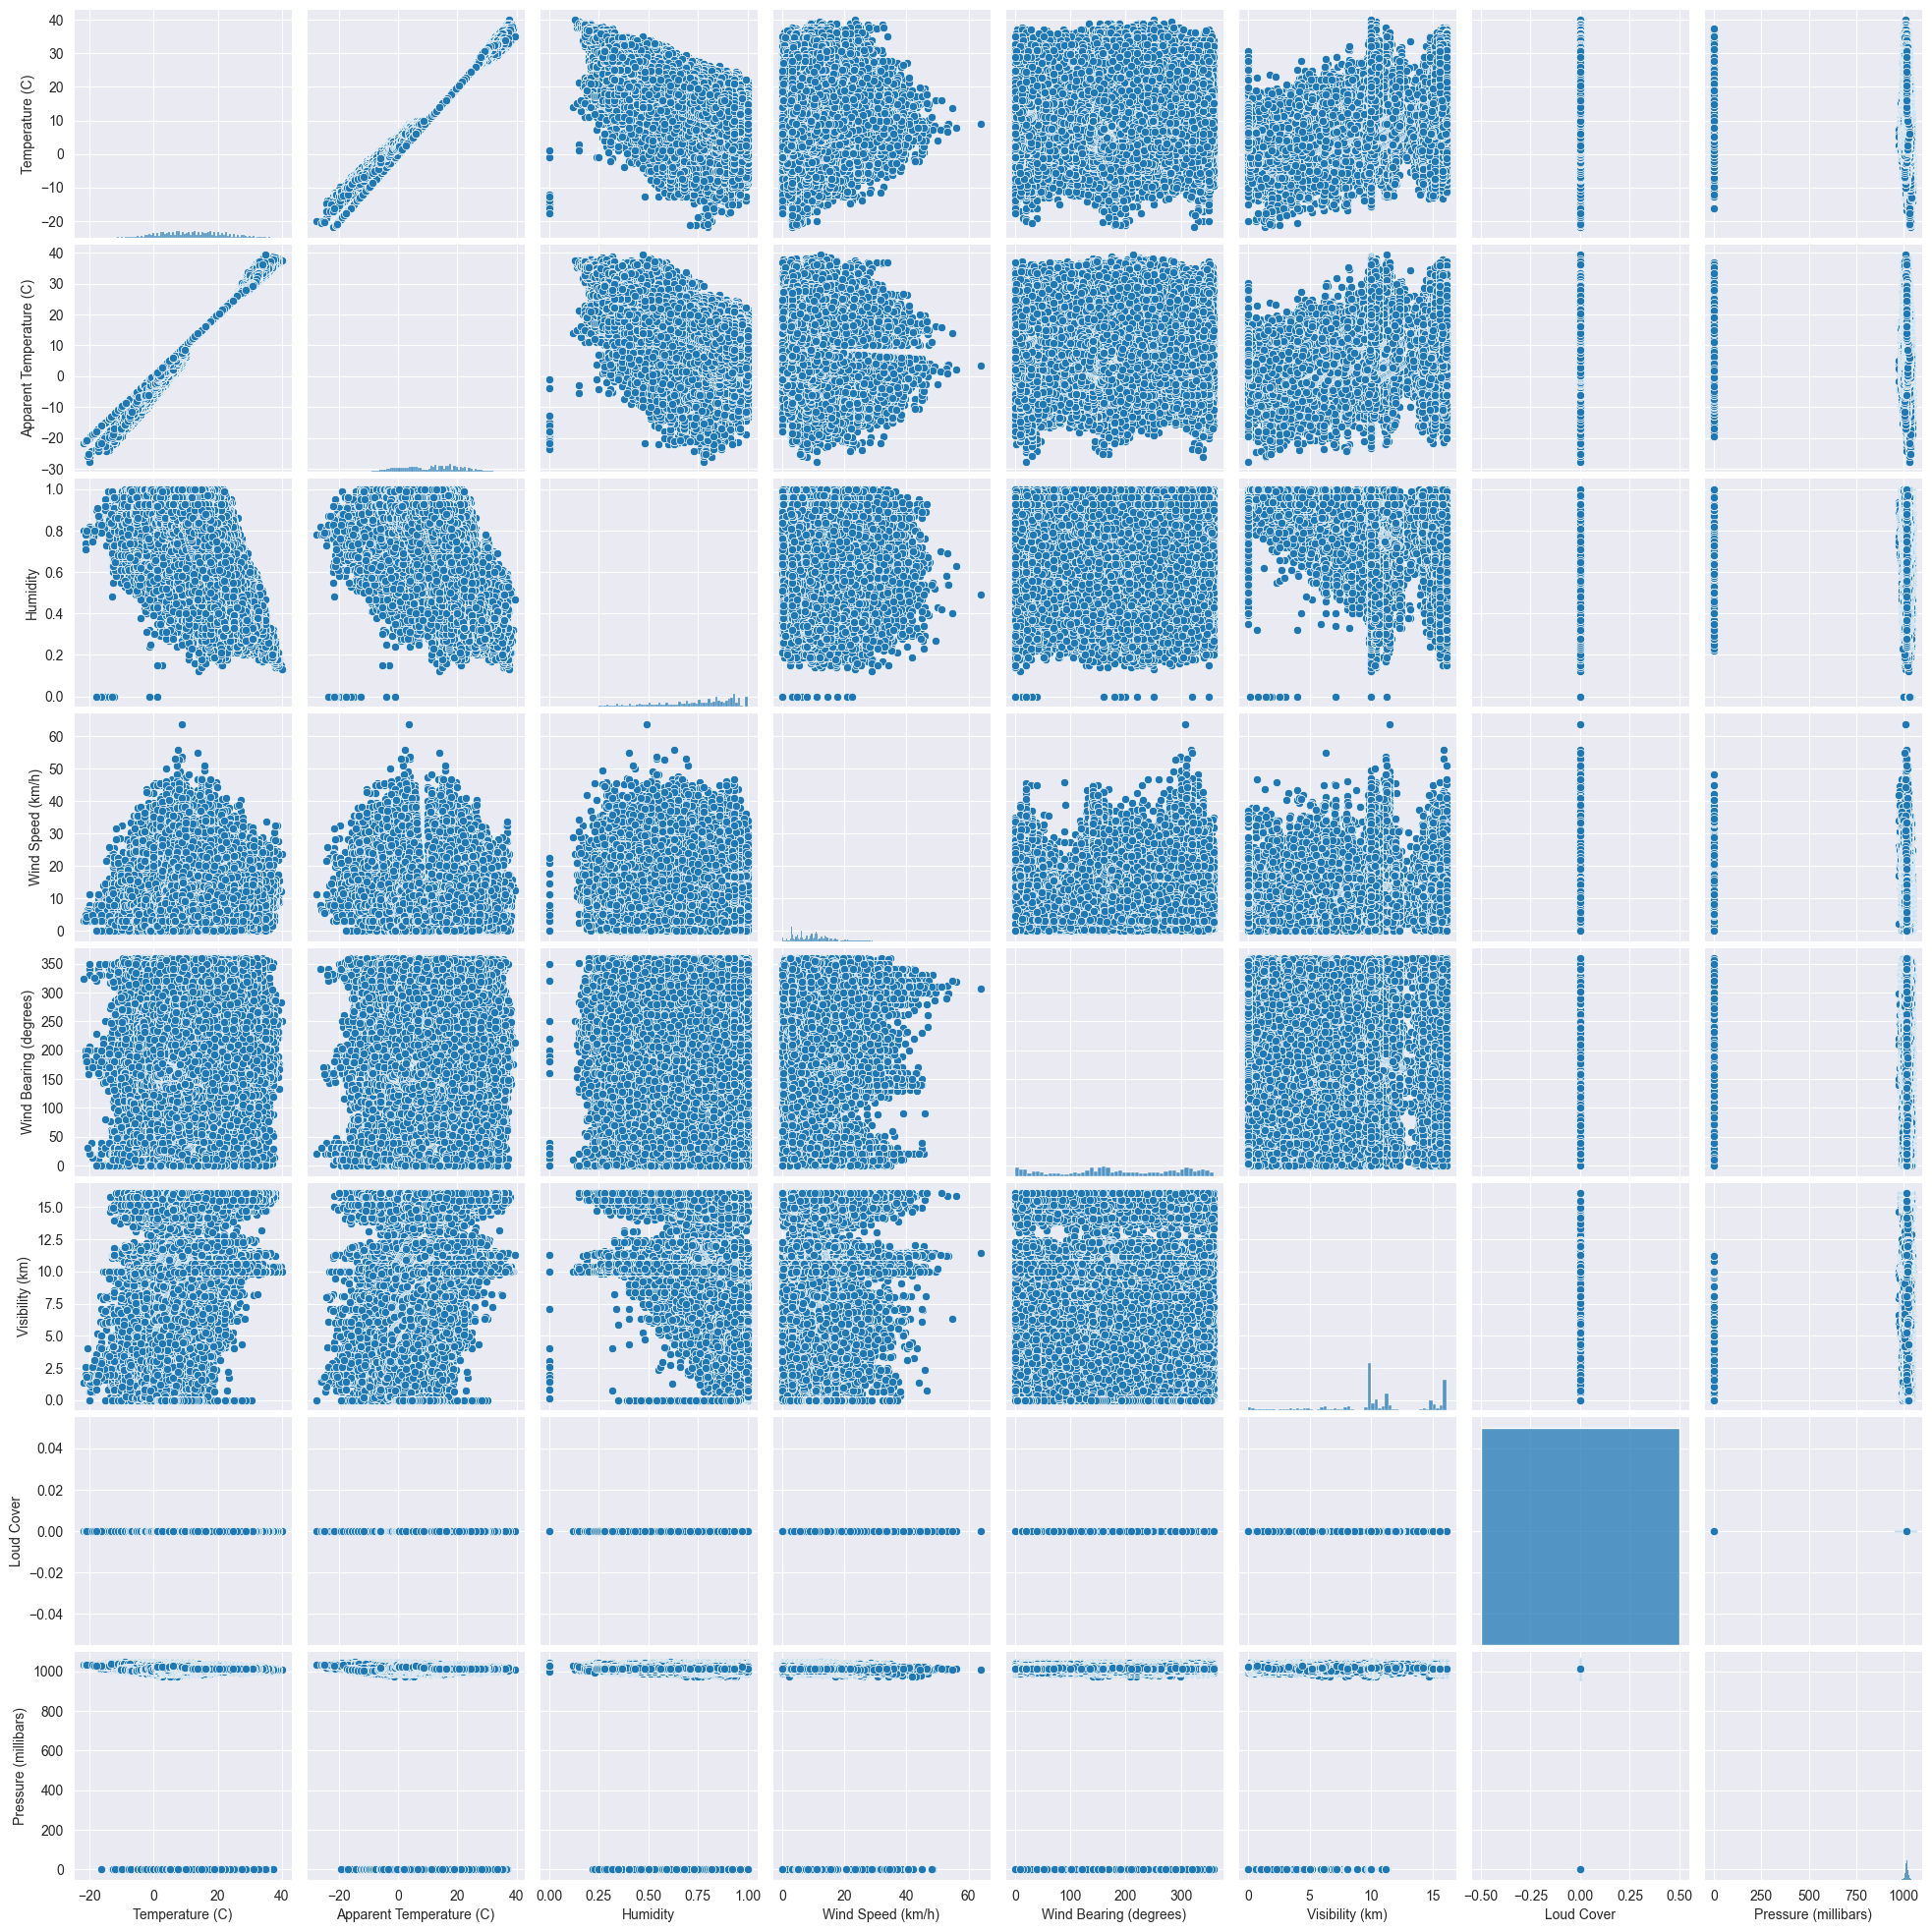

In [25]:
sns.pairplot(df)
plt.show()

Partea de Loud cover este irelevanta. In plus, presiunea atmososferica influenteaza mult prea putin orice alt parametru. Pe langa relatiile discutate anterior, se observa o usoara liniaritate intre umiditate si temperatura, dar cu o eroare reziduala mai mare.Oarecum se grupeaza toate rezultatele catre o directie.Deci sigur, un rol important il va acea senzorul de masurare a umiditatii.

## Curățarea și corectarea datelor

In [26]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [27]:
df['Pressure (millibars)'].value_counts()

Pressure (millibars)
0.00       1288
1017.70     123
1015.00     119
1015.80     118
1018.00     118
           ... 
996.25        1
996.46        1
998.11        1
998.52        1
997.59        1
Name: count, Length: 4979, dtype: int64

Este o problema la senzorul de masurare a presiunii atmosferice. Cele mai multe valori sunt 0.Astfel, unde valoarea este 0 vom inlocui cu media presiunii.

In [28]:
mean_pressure = df[df['Pressure (millibars)'] != 0.0]['Pressure (millibars)'].mean().round(2)
df['Pressure (millibars)'] = df['Pressure (millibars)'].replace(0.0, mean_pressure)

In [29]:
df['Pressure (millibars)'].value_counts()

Pressure (millibars)
1016.81    1347
1017.70     123
1015.00     119
1015.80     118
1018.00     118
           ... 
996.25        1
996.46        1
998.11        1
998.52        1
997.59        1
Name: count, Length: 4978, dtype: int64

Am spus ca nu avem nevoie de coloanele : Date, summary, Apparent Temperature, Loud Cover si daily summary, deci le taiem.Loud cover e doar 0.0, deci nu influenteaza cu nimic.

Incercam sa codificam data masuratorii, deoarece poate in acest mod ne va creste rezultatele. Vom dori sa salvam luna in care are loc masuratoarea si anul. Pe ultima dorim sa o salvam, pentru ca acest dataset se intinde pe o perioada de 10 ani si daca dorim sa il mai extindem, anul va deveni si mai relevant.

Observam cum e formatul datei si adaugam coloanele in dataframe.

In [30]:
df['Formatted Date'].head(5)
df['year'] = 0
df['month'] = 0

In [31]:
import re
pattern = r"(\d+)-(\d+)"
for index,r in df.iterrows():
    date_row = r['Formatted Date']
    match = re.search(pattern,date_row)
    if match:
        year, month = match.groups()
        df.at[index, 'year'] = int(year)
        df.at[index, 'month'] = int(month)

In [32]:
df = df.drop(columns=['Formatted Date', 'Summary', 'Daily Summary','Loud Cover','Apparent Temperature (C)'])
df.head(5)

,Precip Type,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),year,month
0,rain,9.472222,0.89,14.1197,251.0,15.8263,1015.13,2006,4
1,rain,9.355556,0.86,14.2646,259.0,15.8263,1015.63,2006,4
2,rain,9.377778,0.89,3.9284,204.0,14.9569,1015.94,2006,4
3,rain,8.288889,0.83,14.1036,269.0,15.8263,1016.41,2006,4
4,rain,8.755556,0.83,11.0446,259.0,15.8263,1016.51,2006,4


Mai depoarte, vom manipula coloana care ne spune tipul de precipitatie. Unde apare null, vom presupune ca nu exista precipitatii si va fi ca 'none'.In plus, vom folosi tehnica one hot encoding pentru a trece din domeniul de clase/string in numere.

In [33]:
df['Precip Type'] = df['Precip Type'].fillna('none')
df = pd.get_dummies(df,columns=['Precip Type'])

In [34]:
df.head(5)

,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),year,month,Precip Type_none,Precip Type_rain,Precip Type_snow
0,9.472222,0.89,14.1197,251.0,15.8263,1015.13,2006,4,False,True,False
1,9.355556,0.86,14.2646,259.0,15.8263,1015.63,2006,4,False,True,False
2,9.377778,0.89,3.9284,204.0,14.9569,1015.94,2006,4,False,True,False
3,8.288889,0.83,14.1036,269.0,15.8263,1016.41,2006,4,False,True,False
4,8.755556,0.83,11.0446,259.0,15.8263,1016.51,2006,4,False,True,False


In [35]:
df['Precip Type_none'] = df['Precip Type_none'].astype(int)
df['Precip Type_rain'] = df['Precip Type_rain'].astype(int)
df['Precip Type_snow'] = df['Precip Type_snow'].astype(int)
df.head(5)

,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),year,month,Precip Type_none,Precip Type_rain,Precip Type_snow
0,9.472222,0.89,14.1197,251.0,15.8263,1015.13,2006,4,0,1,0
1,9.355556,0.86,14.2646,259.0,15.8263,1015.63,2006,4,0,1,0
2,9.377778,0.89,3.9284,204.0,14.9569,1015.94,2006,4,0,1,0
3,8.288889,0.83,14.1036,269.0,15.8263,1016.41,2006,4,0,1,0
4,8.755556,0.83,11.0446,259.0,15.8263,1016.51,2006,4,0,1,0


Noua forma a datelor:

In [36]:
df.shape

(96453, 11)

In [37]:
df.isnull().sum()

Temperature (C)           0
Humidity                  0
Wind Speed (km/h)         0
Wind Bearing (degrees)    0
Visibility (km)           0
Pressure (millibars)      0
year                      0
month                     0
Precip Type_none          0
Precip Type_rain          0
Precip Type_snow          0
dtype: int64

Acum dorim sa vedem daca s-au modificat niste relatii intre coloane:

<function matplotlib.pyplot.show(close=None, block=None)>

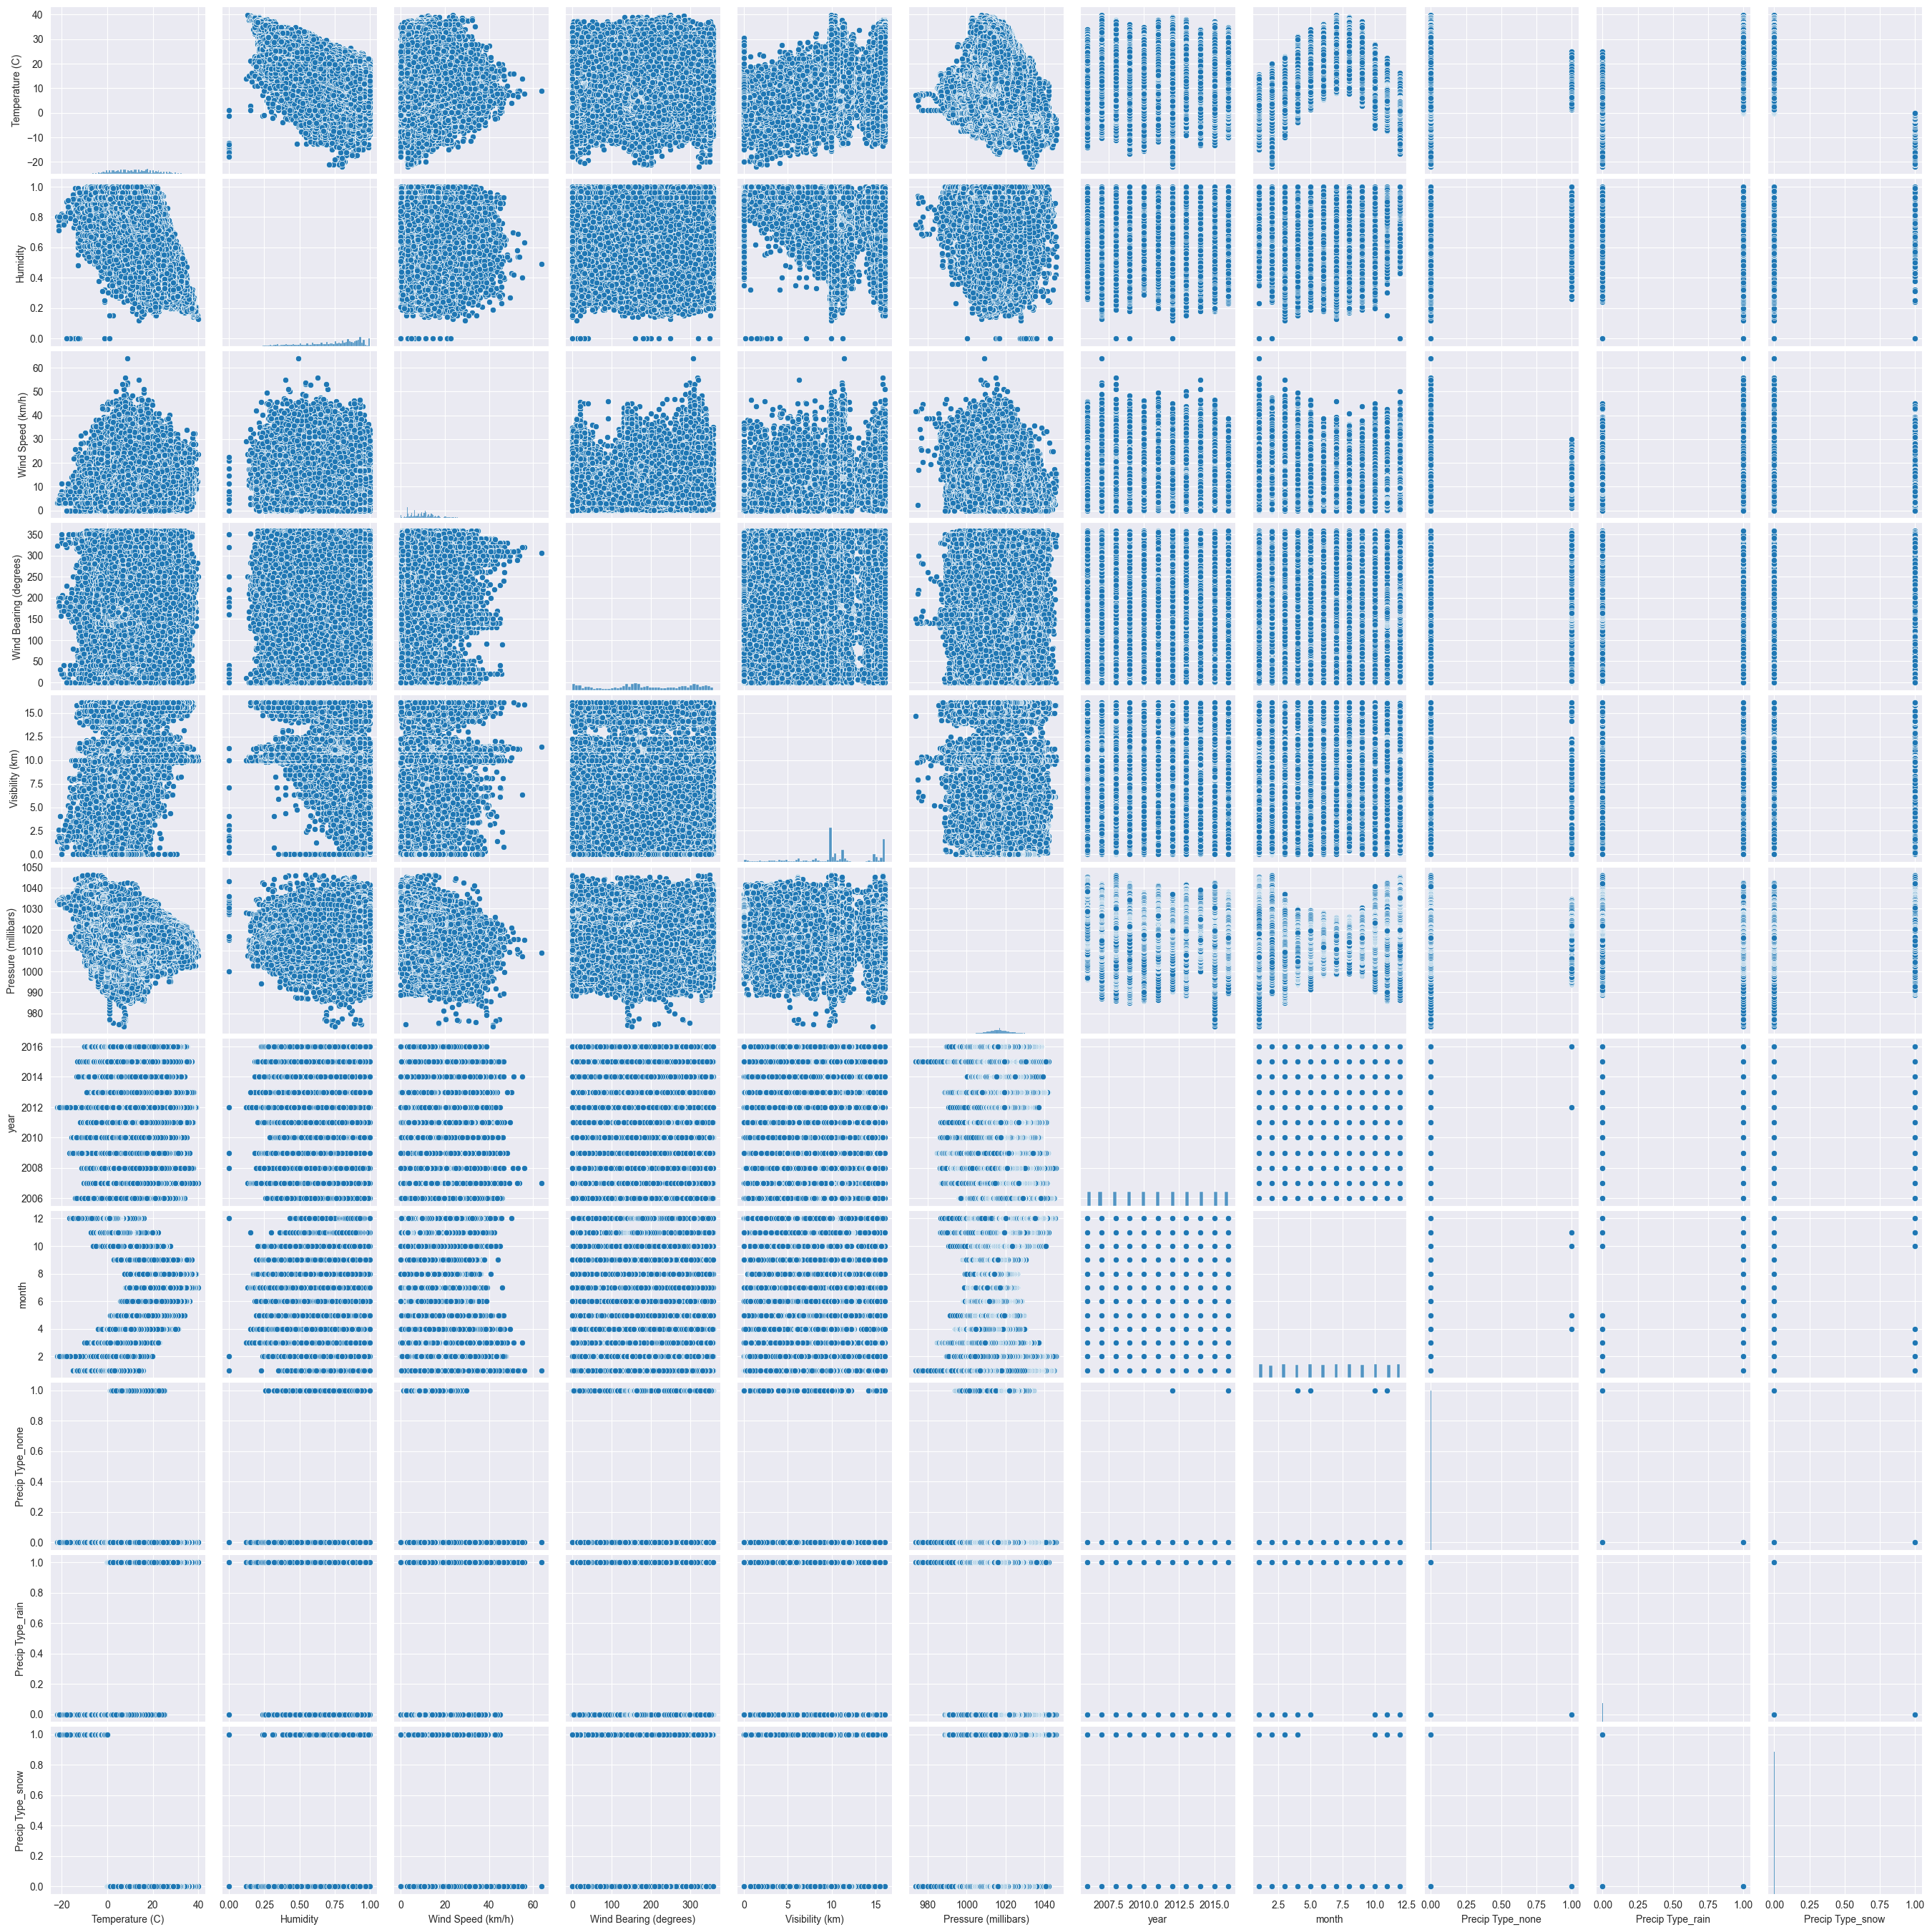

In [38]:
sns.pairplot(df)
plt.show

Observam ca noile coloane(luna si an) ajuta, mai ales luna, deoarece temperatura are forma unei curbe gauss, cu varful in lunile de vara.

# Antrenarea și compararea modelelor de bază:
Se vor folosi mai multe modele de regresie, cum ar fi : regresie liniara, arbori de decizie, xgboost si altele.
Dorim sa vedem urmatoarele statistici :
- MSE :
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

- MAE
$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

- RMSE
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

- $R^2$ : rezultatul este un procent, care ne spune cat la suta din variatia datelor o explica modelul.Pe scurt, cat de bun este modelul.
$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

- O relatie importanta este : $MAE < RMSE$


Acum vom imparti modelul in X(valorile de input) si y(vectorul pe care dorim sa il prezicem). In plus, vom scala valorile, deoarece nu dorim ca un atribut precum presiunea atmosferica, cu un numar mare, sa influenteze mai mult decat umiditatea, desi noi stim corelatiile dintre atribute si nu ar fi adevarat. Asta conteaza la partea matematica de calcul din regresii, in special la modelul bazat pe regresie liniara.

In [45]:
df.to_csv('../Datasets/regresie_date_finale.csv',index=False)

In [46]:
y = df['Temperature (C)']
X = df.drop(columns=['Temperature (C)'])

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=10, test_size=0.25)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 1. Regresia Liniara:
Ce incearca sa faca regresia liniara?
- Trasarea celei mai bune drepte astfel incat eroarea sa fie minima intre exemple. In plus, prezicerea are loc prin calcularea derivatelor partiale si astfel putem determina urmatoarele puncte.
Ecuatia dreptei: $y=mx+b$
- Feedback-ul sau masurarea performantei are loc prin compararea rezultatului prezis cu cel adevarat( se face diferenta).

In [48]:
from sklearn.linear_model import LinearRegression

linear_reg_ml = LinearRegression()
linear_reg_ml.fit(X_train_scaled,y_train)
y_pred_linear = linear_reg_ml.predict(X_test_scaled)
mse_linear = mean_squared_error(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = root_mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test,y_pred_linear)

print(f"MSE:  {mse_linear:.2f}")
print(f"MAE:  {mae_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R²:   {r2_linear:.2f}")


MSE:  29.73
MAE:  4.42
RMSE: 5.45
R²:   0.67


Se poate observa faptul ca eraorea este in jurul valorii de 5.0 grade celsius, iar coeficientul de determinare de 67%.
De mentionat faptul ca cea mai buna masurare pentru eroare este _RMSE_ . Acest model nu ofera niste rezultate foarte bune, din cauza faptului ca, probabil, nu exista niste relatii foarte liniare.

### 2. Decision Tree Regressor
Aceast model de ML este asemanator cu arborii de decizie pentru clasificare. Imparte modelul in grupuri mai mici, deoarece se doareste ca eroare sa fie cat mai mica.Odata cu cresterea inaltimii arborelui, rezultatul va fi mai precis.In loc de clasa, la nivelul de frunza se va afla valoarea prezisa.

In [49]:
from sklearn.tree import DecisionTreeRegressor

tree_ml = DecisionTreeRegressor(random_state=10)
tree_ml.fit(X_train_scaled, y_train)
y_pred_tree = tree_ml.predict(X_test_scaled)
mse_tree = mean_squared_error(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = root_mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"MSE:  {mse_tree:.2f}")
print(f"MAE:  {mae_tree:.2f}")
print(f"RMSE: {rmse_tree:.2f}")
print(f"R²:   {r2_tree:.2f}")


MSE:  10.85
MAE:  2.21
RMSE: 3.29
R²:   0.88


Rezultatul este unul mult mai bun, cu o eroare mica si un factor de determinare si mai bun, de 88%. In acest caz, arborii pot clasifica si imparti datele in zone bune.

### 3.Random Forest Regressor
In aceasta parte, se va analiza modelul care are la baza mai multi arbori de decizie, fiecare avand atribute impartite si analizand partea sa.La final, fiecare va avea o opinie despre rezultatul final, iar output-ul va fi combinatia dintre toate predictiile arborirol de decizie.

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf_ml = RandomForestRegressor(random_state=10)
rf_ml.fit(X_train_scaled, y_train)
y_pred_rf = rf_ml.predict(X_test_scaled)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MSE:  {mse_rf:.2f}")
print(f"MAE:  {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²:   {r2_rf:.2f}")

MSE:  5.38
MAE:  1.70
RMSE: 2.32
R²:   0.94


Random Forest este cel mai bun candidat de pana acum, cu un coeficient de determinare de 94% si eroarea medie la patrat(cea mai buna metrica de calculat a erorii) este de 2.32 grade celsius.

### 4.Support Vector Regressor
SVR se foloseste de o functie kernel pentru a determina cea mai buna curba care poate prezice rezultatele ( curba poate fi inclusiv o dreapta). In calculul matematic, pentru prezicerea valorii continue, stau la baza tot derivatele partiale, care se regasesc si in cazul regresiei liniare.
Kernel-ul poate fi:
- liniar
- rbf(gaussian)
- polinomial
- sigmoid

In [51]:
from sklearn.svm import SVR

svr_ml = SVR() # nu are parametrul de random_state
svr_ml.fit(X_train_scaled, y_train)
y_pred_svr = svr_ml.predict(X_test_scaled)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = root_mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"MSE:  {mse_svr:.2f}")
print(f"MAE:  {mae_svr:.2f}")
print(f"RMSE: {rmse_svr:.2f}")
print(f"R²:   {r2_svr:.2f}")

MSE:  10.42
MAE:  2.50
RMSE: 3.23
R²:   0.88


Coeficientul de determinare este de 88% si o eroare de 3 grade celsius, asemanator cu modelul arborilor de decizie.

### 5. K-Nearest Neighbor Regressor
Acest model de ML cauta cei mai apropiati vecini K (target) si prezice valoarea punctului curent ca fiind media lor.

In [52]:
from sklearn.neighbors import KNeighborsRegressor

knn_ml = KNeighborsRegressor() # nu are parametru de random state
knn_ml.fit(X_train_scaled, y_train)
y_pred_knn = knn_ml.predict(X_test_scaled)
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = root_mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print(f"MSE:  {mse_knn:.2f}")
print(f"MAE:  {mae_knn:.2f}")
print(f"RMSE: {rmse_knn:.2f}")
print(f"R²:   {r2_knn:.2f}")

MSE:  7.63
MAE:  2.01
RMSE: 2.76
R²:   0.92


Rezultate foarte bune, al doilea cel mai bun model, cu un coeficient de determinare de 92% si patratul erorii de 2.76.

### 6.Gaussian Process Regressor
Acest model de ML foloseste tehnica de Superviser Learning si este util atunci cand relatie dintre variabile nu este foarte clara.
Functioneaza pe probabilistica si pe modelul Bayesian.
Este folosita o functie de medie pentru prezicerea valorii. In plus, exista o functie de kernel pentru a gasi cea mai similara functie din exemplele deja testate.

In [53]:
from sklearn.gaussian_process import GaussianProcessRegressor
#kernel-ul este default in aceasta varianta
X_train_sample = X_train_scaled[:5000]
X_test_sample  = X_test_scaled[:5000]
y_train_sample = y_train[:5000] #limitez nr de exemple ca nu poate duce calculatorul mai mult din cauza memoriei RAM
y_test_sample = y_test[:5000]

gpr_ml = GaussianProcessRegressor(random_state=10)
gpr_ml.fit(X_train_sample, y_train_sample)
y_pred_gpr = gpr_ml.predict(X_test_sample)
mse_gpr = mean_squared_error(y_test_sample, y_pred_gpr)
mae_gpr = mean_absolute_error(y_test_sample, y_pred_gpr)
rmse_gpr = root_mean_squared_error(y_test_sample, y_pred_gpr)
r2_gpr = r2_score(y_test_sample, y_pred_gpr)

print(f"MSE:  {mse_gpr:.2f}")
print(f"MAE:  {mae_gpr:.2f}")
print(f"RMSE: {rmse_gpr:.2f}")
print(f"R²:   {r2_gpr:.2f}")


MSE:  43.37
MAE:  4.81
RMSE: 6.59
R²:   0.53


Am redus numarul de randuri analizate din cauza modelului, deoarece consuma foarte multa memorie interna. Am incercat sa iau primele 5000 din tot setul de date, dar exista undeva o eroare/inconsistenta de date, deoarece rezultatele sunt dezastroase si nu corespunde cu datele oferite de celelalte modele.
Rezultatele sunt slabe la 5000, deoarece nu sunt asa multe exemple si in plus nu poate fi comparat cu celelalte modele, deoarece metrica nu este aceeasi.


### 7.XGBoost Regressor
Scopul acestui model este sa minimizeze RMSE sau MSE si implementeaza regularisation pentru a evita overfitting-ul.In XGBoost copacii sunt construiti secvential si fiecare copac interpreteaza datele si le corecteaza, pasandu-le mai departe la urmatorul.In practica, fiecare face o filtrare pentru a iesi un rezultat cat mai bun.


In [54]:
import xgboost as xgb

xgb_ml = xgb.XGBRegressor(random_state=10)
xgb_ml.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_ml.predict(X_test_scaled)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"MSE:  {mse_xgb:.2f}")
print(f"MAE:  {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R²:   {r2_xgb:.2f}")


MSE:  6.88
MAE:  2.03
RMSE: 2.62
R²:   0.92


Coeficientul de determinare este de 92%, iar eroarea RMSE este de 2.62.

### 8.CatBoost Regressor
Acest model implementeaza de asemenea regularizare si ideea lui din spate este aceea de a specula frecventa mediei variabile.O deosebire fata de modelul anterior, CatBoost construieste arbori echilibrati, ceea ce creste performanta.

In [55]:
from catboost import CatBoostRegressor

cat_ml = CatBoostRegressor(random_state=10, verbose=0)
cat_ml.fit(X_train_scaled, y_train)
y_pred_cat = cat_ml.predict(X_test_scaled)
mse_cat = mean_squared_error(y_test, y_pred_cat)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = root_mean_squared_error(y_test, y_pred_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print(f"MSE:  {mse_cat:.2f}")
print(f"MAE:  {mae_cat:.2f}")
print(f"RMSE: {rmse_cat:.2f}")
print(f"R²:   {r2_cat:.2f}")


MSE:  7.00
MAE:  2.06
RMSE: 2.65
R²:   0.92


### 9.Explainable Boosting Regressor
Este un model asemanator cu XGBoost. Algoritmul invata influenta fiecarei variabile separat.

In [56]:
from interpret.glassbox import ExplainableBoostingRegressor

ebr_ml = ExplainableBoostingRegressor(random_state=10)
ebr_ml.fit(X_train_scaled, y_train)
y_pred_ebr = ebr_ml.predict(X_test_scaled)
mse_ebr = mean_squared_error(y_test, y_pred_ebr)
mae_ebr = mean_absolute_error(y_test, y_pred_ebr)
rmse_ebr = root_mean_squared_error(y_test, y_pred_ebr)
r2_ebr = r2_score(y_test, y_pred_ebr)

print(f"MSE:  {mse_ebr:.2f}")
print(f"MAE:  {mae_ebr:.2f}")
print(f"RMSE: {rmse_ebr:.2f}")
print(f"R²:   {r2_ebr:.2f}")


MSE:  7.71
MAE:  2.17
RMSE: 2.78
R²:   0.91


Are rezultate asemanatoare cu modelele anterioare. Singurul dezavantaj ar fi timpul de executie care este mult mai mare fata de celelalte modele de tipul boost.

## Analiza comparativa intre modelele de baza:

- facem un df cu toate metricile de la fiecare model
- _Nota_ : nu am mai adaugat modelul bazat pe formula gaussiana, deoarece s-ar deforma graficele.

In [57]:
model_base_grid = {
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'SVR',
        'KNN',
        'XGBoost',
        'CatBoost',
        'EBM'
    ],
    'MSE': [mse_linear, mse_tree, mse_rf, mse_svr, mse_knn, mse_xgb, mse_cat, mse_ebr],
    'MAE': [mae_linear, mae_tree, mae_rf, mae_svr, mae_knn, mae_xgb, mae_cat, mae_ebr],
    'RMSE': [rmse_linear, rmse_tree, rmse_rf, rmse_svr, rmse_knn, rmse_xgb, rmse_cat, rmse_ebr],
    'R2-score': [r2_linear, r2_tree, r2_rf, r2_svr, r2_knn, r2_xgb, r2_cat, r2_ebr]
}

df_model_base = pd.DataFrame(model_base_grid)

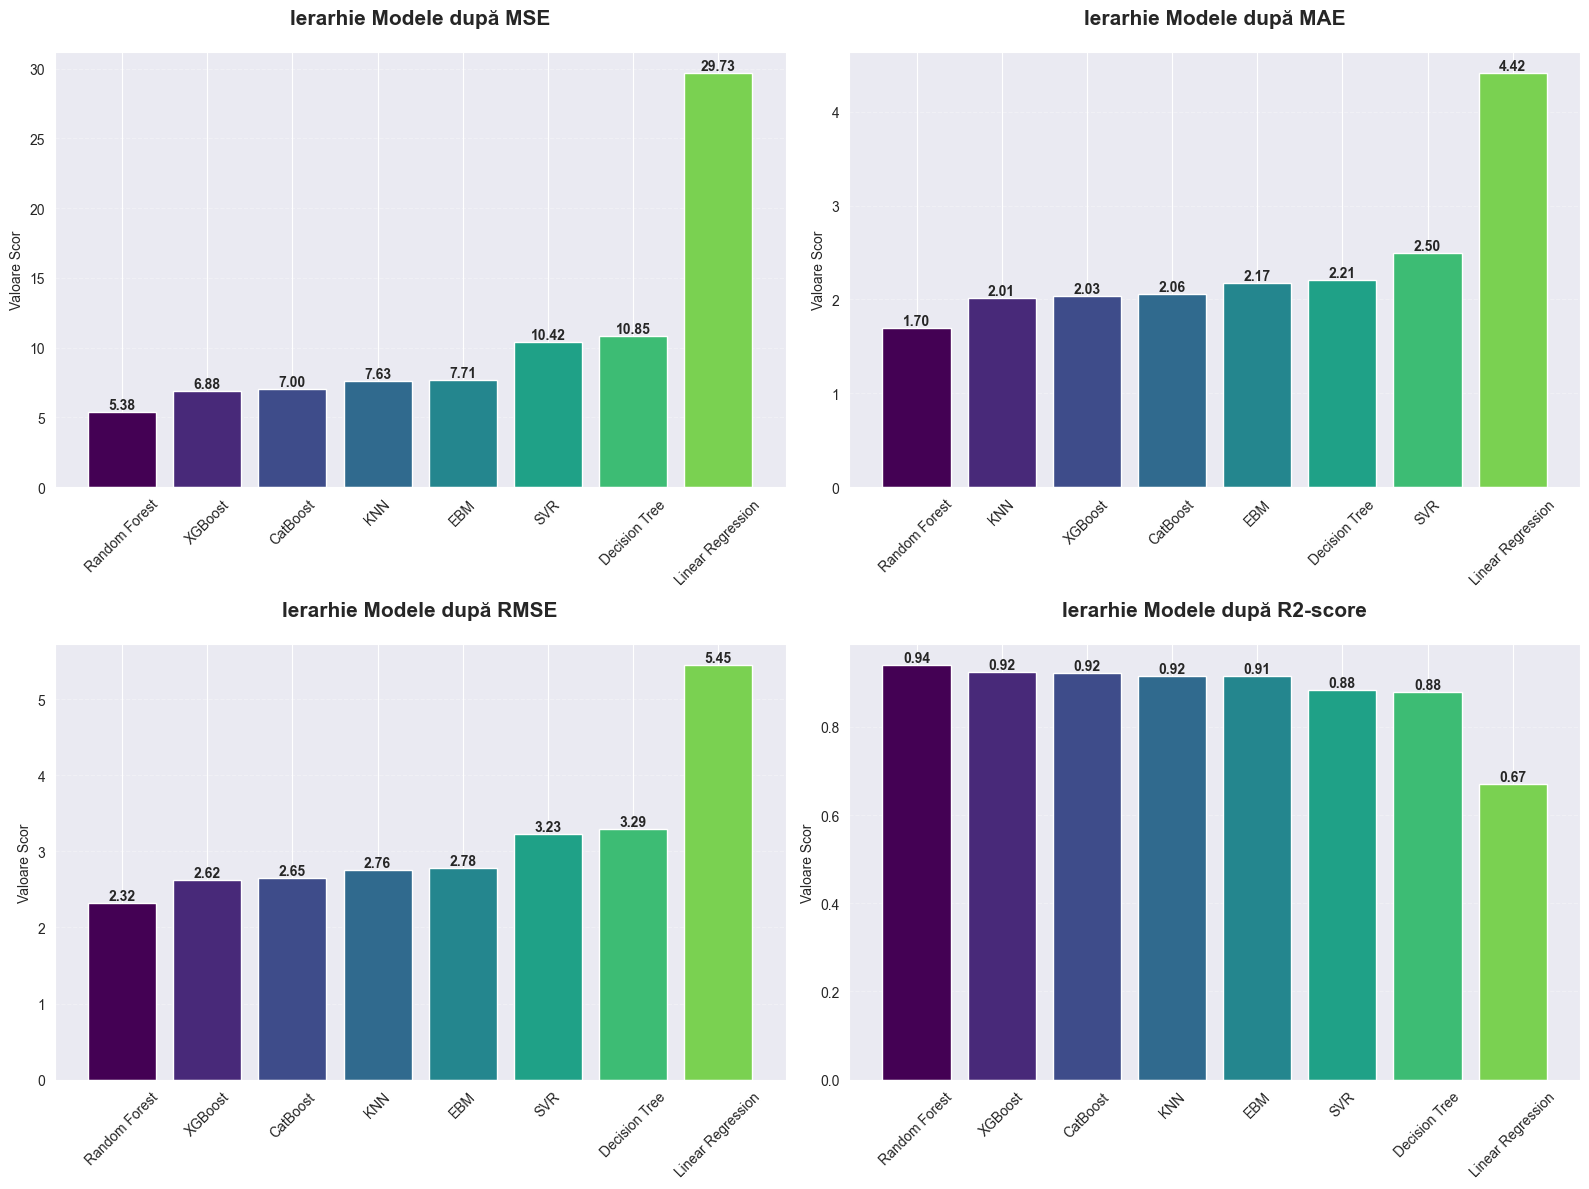

In [58]:
import matplotlib.pyplot as plt
import numpy as np

metric_names = ['MSE', 'MAE', 'RMSE', 'R2-score']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

nume_modele = model_base_grid['Model']

for i, metric in enumerate(metric_names):
    scoruri_metrica = model_base_grid[metric]

    data = list(zip(nume_modele, scoruri_metrica))
    if metric == 'R2-score':
        data.sort(key=lambda x: x[1], reverse=True)
    else:
        data.sort(key=lambda x: x[1])
    models, values = zip(*data)
    color_map = plt.cm.viridis(np.linspace(0, 0.8, len(models)))
    bars = axes[i].bar(models, values, color=color_map)

    axes[i].set_title(f'Ierarhie Modele după {metric}', fontsize=15, fontweight='bold', pad=20)
    axes[i].set_ylabel('Valoare Scor')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)
    for bar in bars:
        yval = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Acum vom adauga un scor in functie de cel mai mare scor, iar modelul care are cea mai mare suma este cel mai bun.
Pentru fiecare metrica, adaugam un score la fiecare model din top 5.Deja se observa faptul ca Random Forest este cel mai bun.

In [59]:
df_model_base['Score'] = 0
score_sort = df_model_base.sort_values(by='R2-score', ascending=False)
score_sort.loc[score_sort.index[:5],'Score'] += [5,4,3,2,1]
score_sort

,Model,MSE,MAE,RMSE,R2-score,Score
2,Random Forest,5.381194,1.699099,2.319740,0.940518,5
5,XGBoost,6.879266,2.033625,2.622835,0.923959,4
6,CatBoost,6.996882,2.059914,2.645162,0.922659,3
4,KNN,7.625642,2.010625,2.761457,0.915708,2
7,EBM,7.712517,2.172670,2.777142,0.914748,1
3,SVR,10.424082,2.499376,3.228635,0.884775,0
1,Decision Tree,10.849623,2.210185,3.293877,0.880071,0
0,Linear Regression,29.726170,4.420288,5.452171,0.671416,0


La erori luam ordinea crescatoare, deoarece dorim sa 'premiem' modelele cu cea mai mica eroare.

In [60]:
score_sort = score_sort.sort_values(by='MAE', ascending=True)
score_sort.loc[score_sort.index[:5],'Score'] += [5,4,3,2,1]
score_sort.sort_values(by='Score',ascending=False)

,Model,MSE,MAE,RMSE,R2-score,Score
2,Random Forest,5.381194,1.699099,2.319740,0.940518,10
5,XGBoost,6.879266,2.033625,2.622835,0.923959,7
4,KNN,7.625642,2.010625,2.761457,0.915708,6
6,CatBoost,6.996882,2.059914,2.645162,0.922659,5
7,EBM,7.712517,2.172670,2.777142,0.914748,2
1,Decision Tree,10.849623,2.210185,3.293877,0.880071,0
3,SVR,10.424082,2.499376,3.228635,0.884775,0
0,Linear Regression,29.726170,4.420288,5.452171,0.671416,0


In [61]:
score_sort = score_sort.sort_values(by='RMSE', ascending=True)
score_sort.loc[score_sort.index[:5],'Score'] += [5,4,3,2,1]
score_sort.sort_values(by='Score',ascending=False)

,Model,MSE,MAE,RMSE,R2-score,Score
2,Random Forest,5.381194,1.699099,2.319740,0.940518,15
5,XGBoost,6.879266,2.033625,2.622835,0.923959,11
6,CatBoost,6.996882,2.059914,2.645162,0.922659,8
4,KNN,7.625642,2.010625,2.761457,0.915708,8
7,EBM,7.712517,2.172670,2.777142,0.914748,3
3,SVR,10.424082,2.499376,3.228635,0.884775,0
1,Decision Tree,10.849623,2.210185,3.293877,0.880071,0
0,Linear Regression,29.726170,4.420288,5.452171,0.671416,0


In [62]:
score_sort = score_sort.sort_values(by='MSE', ascending=True)
score_sort.loc[score_sort.index[:5],'Score'] += [5,4,3,2,1]
score_sort.sort_values(by='Score',ascending=False)

,Model,MSE,MAE,RMSE,R2-score,Score
2,Random Forest,5.381194,1.699099,2.319740,0.940518,20
5,XGBoost,6.879266,2.033625,2.622835,0.923959,15
6,CatBoost,6.996882,2.059914,2.645162,0.922659,11
4,KNN,7.625642,2.010625,2.761457,0.915708,10
7,EBM,7.712517,2.172670,2.777142,0.914748,4
3,SVR,10.424082,2.499376,3.228635,0.884775,0
1,Decision Tree,10.849623,2.210185,3.293877,0.880071,0
0,Linear Regression,29.726170,4.420288,5.452171,0.671416,0


Top 5 modele de baza :

In [63]:
score_sort.sort_values(by='Score',ascending=False).head(5)

,Model,MSE,MAE,RMSE,R2-score,Score
2,Random Forest,5.381194,1.699099,2.319740,0.940518,20
5,XGBoost,6.879266,2.033625,2.622835,0.923959,15
6,CatBoost,6.996882,2.059914,2.645162,0.922659,11
4,KNN,7.625642,2.010625,2.761457,0.915708,10
7,EBM,7.712517,2.172670,2.777142,0.914748,4


Putem observa faptul ca modelele boost sunt cele mai performante.

## Ajustarea hiperparametrilor si Curbele de învățare:
In aceasta parte a notebook-ului, vom lua cele mai bune modele selectate anterior, le vom gasi cei mai buni parametrii si vom analiza curbele de invatare ca sa ne asiguram ca nu avem overfitting sau underfitting.

### 1.CatBoost Regressor

Am luat un set de date mai mic, de 20k , pentru a nu dura foarte mult rularea hiperparametrizarii... Consider ca acest numar este suficient pentru parametrizare.

In [85]:
X_train_search = X_train_scaled[:10000]
X_test_search = X_test_scaled[:10000]
y_train_search = y_train[:10000]
y_test_search = y_test[:10000]

In [86]:
cat_grid = {
    'iterations': [1000],
    'depth': [4,6],
    'learning_rate': [0.01, 0.05],
    'l2_leaf_reg': [3,4,5]
}

cat_search = GridSearchCV(
    param_grid=cat_grid,
    estimator=cat_ml,
    verbose=2,
    cv=5,
    n_jobs=-1
)

cat_search.fit(X_train_search, y_train_search)
best_cat_model = cat_search.best_estimator_
y_pred_cat_opt = best_cat_model.predict(X_test_search)
mse_cat_opt = mean_squared_error(y_test_search, y_pred_cat_opt)
mae_cat_opt = mean_absolute_error(y_test_search, y_pred_cat_opt)
rmse_cat_opt = np.sqrt(mse_cat_opt)
r2_cat_opt = r2_score(y_test_search, y_pred_cat_opt)

print(f"Parametrii optimi gasiti: {cat_search.best_params_}")
print(f"MSE:  {mse_cat_opt:.2f}")
print(f"MAE:  {mae_cat_opt:.2f}")
print(f"RMSE: {rmse_cat_opt:.2f}")
print(f"R²:   {r2_cat_opt:.2f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Parametrii optimi gasiti: {'depth': 6, 'iterations': 1000, 'l2_leaf_reg': 4, 'learning_rate': 0.05}
MSE:  8.45
MAE:  2.27
RMSE: 2.91
R²:   0.91


In [87]:
import joblib
joblib.dump(cat_ml, '../Models/base_cat.pkl')
joblib.dump(best_cat_model, '../Models/opt_cat.pkl')

['../Models/opt_cat.pkl']

In [88]:
joblib.dump(scaler, '../Models/scaler.pkl')

['../Models/scaler.pkl']

Nu exista mare diferenta, chiar foarte putin mai slab.

Curba de invatare:

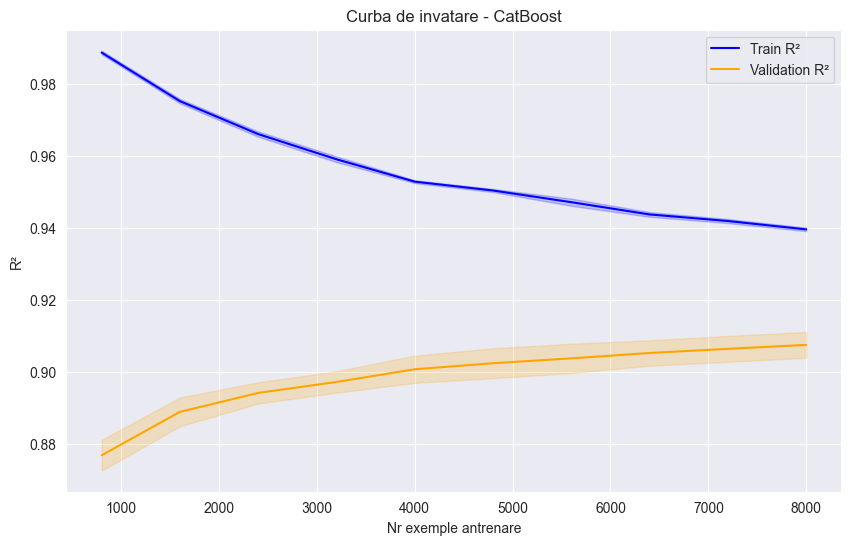

In [89]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_cat_model,
    X=X_train_search,
    y=y_train_search,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train R²', color='blue')
plt.plot(train_sizes, val_mean, label='Validation R²', color='orange')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange')
plt.xlabel('Nr exemple antrenare')
plt.ylabel('R²')
plt.title('Curba de invatare - CatBoost')
plt.legend()
plt.grid(True)
plt.show()

In curba de invatare prezentata mai sus, nu exista overfitting, deoarece gap-ul intre curba de antrenare si validare este mic, doar de 0.04 si de asemenea nu este underfitting.

### 2. XGBoost Regressor

In [90]:
xgb_grid = {
    'n_estimators': [1000],
    'max_depth': [4,6],
    'learning_rate': [0.01,0.03, 0.05],
    'reg_lambda': [1, 5, 10],
    'reg_alpha': [0,1],
    'subsample': [0.8]
}

xgb_search = GridSearchCV(
    param_grid=xgb_grid,
    estimator=xgb_ml,
    verbose=2,
    cv=5,
    n_jobs=-1
)

xgb_search.fit(X_train_search, y_train_search)
best_xgb_model = xgb_search.best_estimator_
y_pred_xgb_opt = best_xgb_model.predict(X_test_search)
mse_xgb_opt = mean_squared_error(y_test_search, y_pred_xgb_opt)
mae_xgb_opt = mean_absolute_error(y_test_search, y_pred_xgb_opt)
rmse_xgb_opt = np.sqrt(mse_xgb_opt)
r2_xgb_opt = r2_score(y_test_search, y_pred_xgb_opt)

print(f"Parametrii optimi gasiti: {xgb_search.best_params_}")
print(f"MSE:  {mse_xgb_opt:.2f}")
print(f"MAE:  {mae_xgb_opt:.2f}")
print(f"RMSE: {rmse_xgb_opt:.2f}")
print(f"R²:   {r2_xgb_opt:.2f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Parametrii optimi gasiti: {'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 1000, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 0.8}
MSE:  8.32
MAE:  2.25
RMSE: 2.89
R²:   0.91


In [91]:
joblib.dump(xgb_ml, '../Models/base_xgb.pkl')
joblib.dump(best_xgb_model, '../Models/opt_xgb.pkl')

['../Models/opt_xgb.pkl']

Rezultate asemanatoare ca modelul anterior si cu cel de baza.

Curba de invatare:

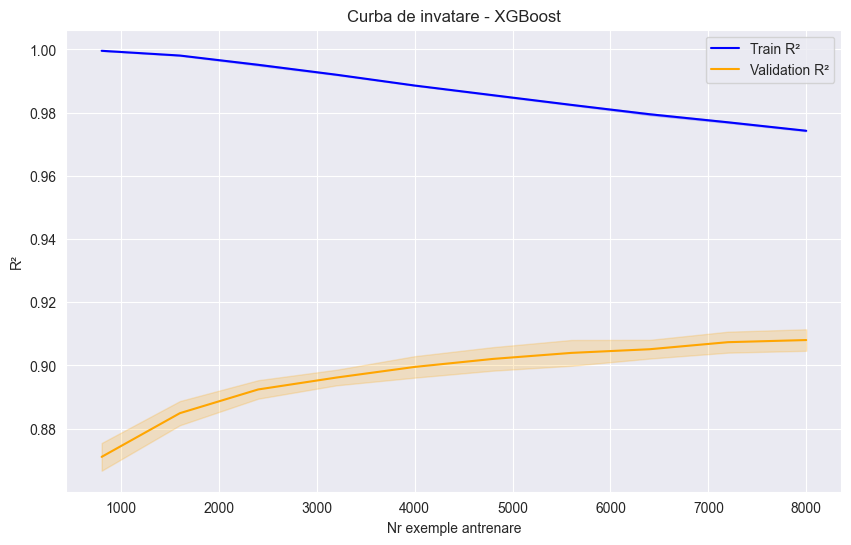

In [92]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_xgb_model,
    X=X_train_search,
    y=y_train_search,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train R²', color='blue')
plt.plot(train_sizes, val_mean, label='Validation R²', color='orange')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange')
plt.xlabel('Nr exemple antrenare')
plt.ylabel('R²')
plt.title('Curba de invatare - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

De asemenea nu prezinta overfit sau underfit, curba de antrenare este foarte lina si scade usor, in timp ce curba de validare creste logaritmic.Distanta dintre curbe este mai mare fata de modelul anterior, insa se incadreaza in cazul de overfit.

### 3.Random Forest Regressor

In [93]:
rf_grid = {
    'n_estimators': [300], #reduc nr de arbori din cauza memoriei ram
    'max_depth': [10, 12],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt'],
}

rf_search = GridSearchCV(
    param_grid=rf_grid,
    estimator=rf_ml,
    verbose=2,
    cv=5,
    n_jobs=-1
)

rf_search.fit(X_train_search, y_train_search)
best_rf_model = rf_search.best_estimator_
y_pred_rf_opt = best_rf_model.predict(X_test_search)
mse_rf_opt = mean_squared_error(y_test_search, y_pred_rf_opt)
mae_rf_opt = mean_absolute_error(y_test_search, y_pred_rf_opt)
rmse_rf_opt = np.sqrt(mse_rf_opt)
r2_rf_opt = r2_score(y_test_search, y_pred_rf_opt)

print(f"Parametrii optimi gasiti: {rf_search.best_params_}")
print(f"MSE:  {mse_rf_opt:.2f}")
print(f"MAE:  {mae_rf_opt:.2f}")
print(f"RMSE: {rmse_rf_opt:.2f}")
print(f"R²:   {r2_rf_opt:.2f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Parametrii optimi gasiti: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 300}
MSE:  10.20
MAE:  2.52
RMSE: 3.19
R²:   0.89


Pentru hipermetrizarea random forest-ului am pus foarte putini parametrii din cauza memoriei interne. Totusi, rezultatele sunt similare si limitarea acestui dataset ar fi de aproximativ 89%. Mai slab fata de modelul de baza, probabil si din cauza faptului ca am redus spatiul de cautare pentru modelul cel mai bun in favoarea timpului.

In [94]:
joblib.dump(rf_ml, '../Models/base_rf.pkl')
joblib.dump(best_rf_model, '../Models/opt_rf.pkl')


['../Models/opt_rf.pkl']

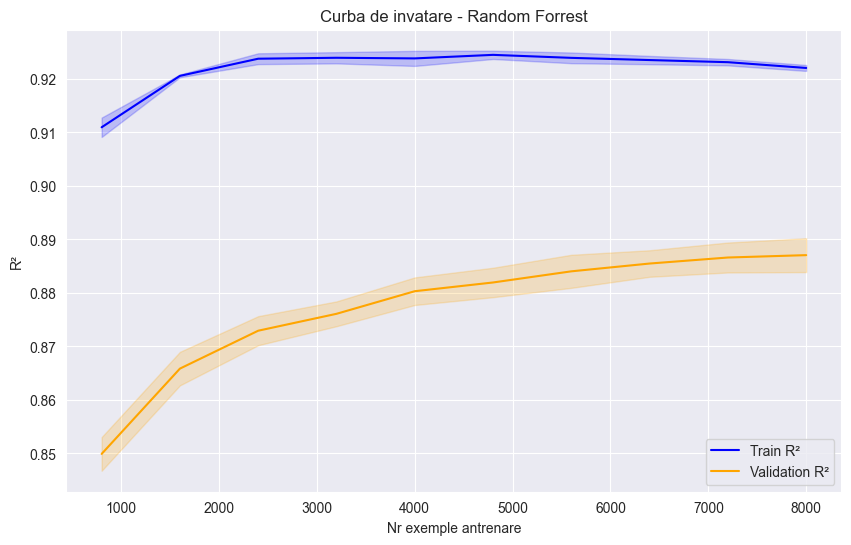

In [95]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_rf_model,
    X=X_train_search,
    y=y_train_search,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train R²', color='blue')
plt.plot(train_sizes, val_mean, label='Validation R²', color='orange')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange')
plt.xlabel('Nr exemple antrenare')
plt.ylabel('R²')
plt.title('Curba de invatare - Random Forrest')
plt.legend()
plt.grid(True)
plt.show()

Totusi, vestea buna este faptul ca nu exista overfitting, gap-ul intre de train si validare este < 0.10 , fiind acceptabil. Asadar, modelul generalizeaza bine. Daca diferenta ar fi fost foarte mica intre cele 2 curbe, de ordinul sutimilor, atunci ne-am fi aflat intr-un caz de underfitting.

### 4.Explainable Boosting Regressor

In [96]:
ebr_grid = {
    'learning_rate': [0.01, 0.05], # am incercat si cu alti parametrii dar dureaza prea mult , am asteptat si > 30min
    'interactions': [10],
    'max_bins': [256],
    'min_samples_leaf': [2, 5],
    'inner_bags': [0],
}

ebr_search = GridSearchCV(
    param_grid=ebr_grid,
    estimator=ebr_ml,
    verbose=2,
    cv=5,
    n_jobs=-1
)

ebr_search.fit(X_train_search, y_train_search)
best_ebr_model = ebr_search.best_estimator_
y_pred_ebr_opt = best_ebr_model.predict(X_test_search)
mse_ebr_opt = mean_squared_error(y_test_search, y_pred_ebr_opt)
mae_ebr_opt = mean_absolute_error(y_test_search, y_pred_ebr_opt)
rmse_ebr_opt = np.sqrt(mse_ebr_opt)
r2_ebr_opt = r2_score(y_test_search, y_pred_ebr_opt)

print(f"Parametrii optimi gasiti: {ebr_search.best_params_}")
print(f"MSE:  {mse_ebr_opt:.2f}")
print(f"MAE:  {mae_ebr_opt:.2f}")
print(f"RMSE: {rmse_ebr_opt:.2f}")
print(f"R²:   {r2_ebr_opt:.2f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Parametrii optimi gasiti: {'inner_bags': 0, 'interactions': 10, 'learning_rate': 0.05, 'max_bins': 256, 'min_samples_leaf': 2}
MSE:  9.38
MAE:  2.40
RMSE: 3.06
R²:   0.90


In [97]:
joblib.dump(rf_ml, '../Models/base_ebr.pkl')
joblib.dump(best_rf_model, '../Models/opt_ebr.pkl')


['../Models/opt_ebr.pkl']

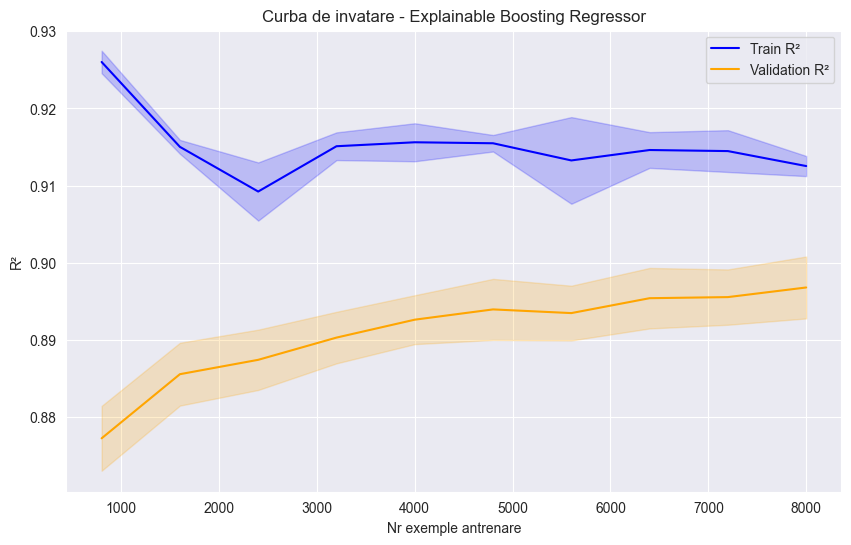

In [98]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_ebr_model,
    X=X_train_search,
    y=y_train_search,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train R²', color='blue')
plt.plot(train_sizes, val_mean, label='Validation R²', color='orange')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange')
plt.xlabel('Nr exemple antrenare')
plt.ylabel('R²')
plt.title('Curba de invatare - Explainable Boosting Regressor')
plt.legend()
plt.grid(True)
plt.show()

Curbele de invatare arata bine, nu prezinta semne de overfitting sau underfitting. In plus, curba de validare este intr-o continua crestere(pare logaritmica, dar conteaza ca este crescatoare functia). In plus, putem deduce faptul ca limitarea dataset-ului are loc in vecinatatea scorului de 90% pentru coeficientul de determinare. Din fluctuatiile curbei train mai putem deduce faptul ca acest model cu siguranta nu face overfitting, nu invata foarte bine valorile de antrenare.

### 5. K-Nearest Neighbors

In [99]:
knn_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform'],
    'metric': ['euclidean', 'manhattan'],
    'algorithm': ['auto']
}

knn_search = GridSearchCV(
    param_grid=knn_grid,
    estimator=knn_ml,
    verbose=2,
    cv=5,
    n_jobs=-1
)

knn_search.fit(X_train_search, y_train_search)
best_knn_model = knn_search.best_estimator_
y_pred_knn_opt = best_knn_model.predict(X_test_search)
mse_knn_opt = mean_squared_error(y_test_search, y_pred_knn_opt)
mae_knn_opt = mean_absolute_error(y_test_search, y_pred_knn_opt)
rmse_knn_opt = np.sqrt(mse_knn_opt)
r2_knn_opt = r2_score(y_test_search, y_pred_knn_opt)

print(f"Parametrii optimi gasiti: {knn_search.best_params_}")
print(f"MSE:  {mse_knn_opt:.2f}")
print(f"MAE:  {mae_knn_opt:.2f}")
print(f"RMSE: {rmse_knn_opt:.2f}")
print(f"R²:   {r2_knn_opt:.2f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Parametrii optimi gasiti: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
MSE:  11.60
MAE:  2.61
RMSE: 3.41
R²:   0.87


In [100]:
joblib.dump(rf_ml, '../Models/base_knn.pkl')
joblib.dump(best_rf_model, '../Models/opt_knn.pkl')


['../Models/opt_knn.pkl']

Curba de invatare pentru knn:

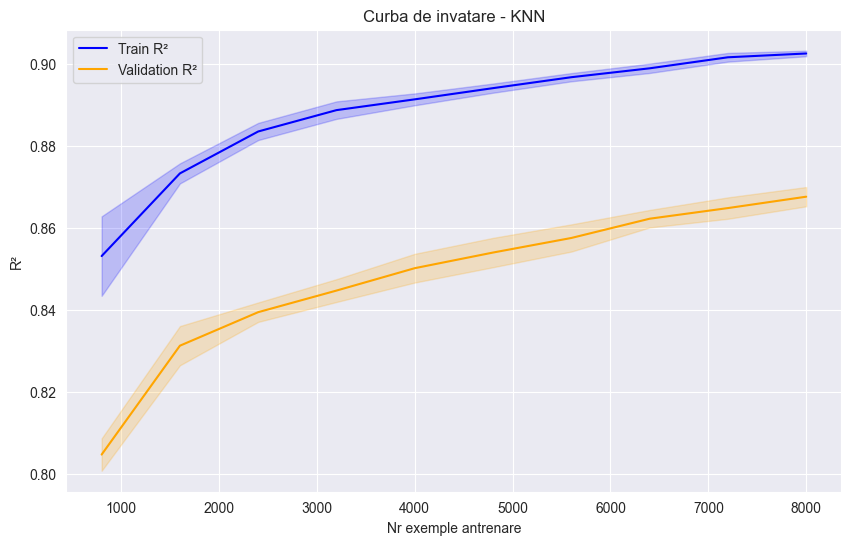

In [101]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_knn_model,
    X=X_train_search,
    y=y_train_search,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train R²', color='blue')
plt.plot(train_sizes, val_mean, label='Validation R²', color='orange')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange')
plt.xlabel('Nr exemple antrenare')
plt.ylabel('R²')
plt.title('Curba de invatare - KNN')
plt.legend()
plt.grid(True)
plt.show()

Acest model nu prezinta nici el de asemenea fenomenul de underfitting sau overfitting. Curba de validare creste de asemenea logaritmic, iar rezultatele se situeaza in aceeasi zona de 0.89 .

Concluzii :
Optimizarea nu a reusit, exista rezultate foarte asemanatoare fata de modelele de baza. Acest lucru se datoreaza in principiu din cauza a 2 factori:
- dataset-ul : poate fi imbunatatit cu mai multi senzori sau sa existe o codificare extrema despre orice atribut( nu sa elimin cateva coloane, asa cum am facut).
- puterea de procesare : in principiu, pentru a nu astepta perioade mari de timp, am redus dataset-ul astfel incat timpul sa fie acceptabil.

Un aspect pozitiv il reprezinta absenta fenomenelor grave de underfitting sau overfitting.

Un ajutor in plus, este faptul ca am adaugat coloanele de luna si an,care au ajutat considerabil modelul sa creasca predictiile.

#### Ierarhizarea modelelor optimizare:

In [124]:
opt_model = {
    'Model' : ['Explainable Boosting Regressor', 'XGBoost Regressor', 'CatBoost Regressor', 'Random Forest Regressor', 'K-Nearest Neighbors Regressor'],
    'MSE' : [mse_ebr_opt, mse_xgb_opt, mse_cat_opt, mse_rf_opt, mse_knn_opt],
    'MAE' : [mae_ebr_opt, mae_xgb_opt, mae_cat_opt, mae_rf_opt, mae_knn_opt],
    'RMSE' : [rmse_ebr_opt, rmse_xgb_opt, rmse_cat_opt, rmse_rf_opt, rmse_knn_opt],
    'R2-score' : [r2_ebr_opt, r2_xgb_opt, r2_cat_opt, r2_rf_opt, r2_knn_opt]
}

df_opt_model = pd.DataFrame(opt_model)

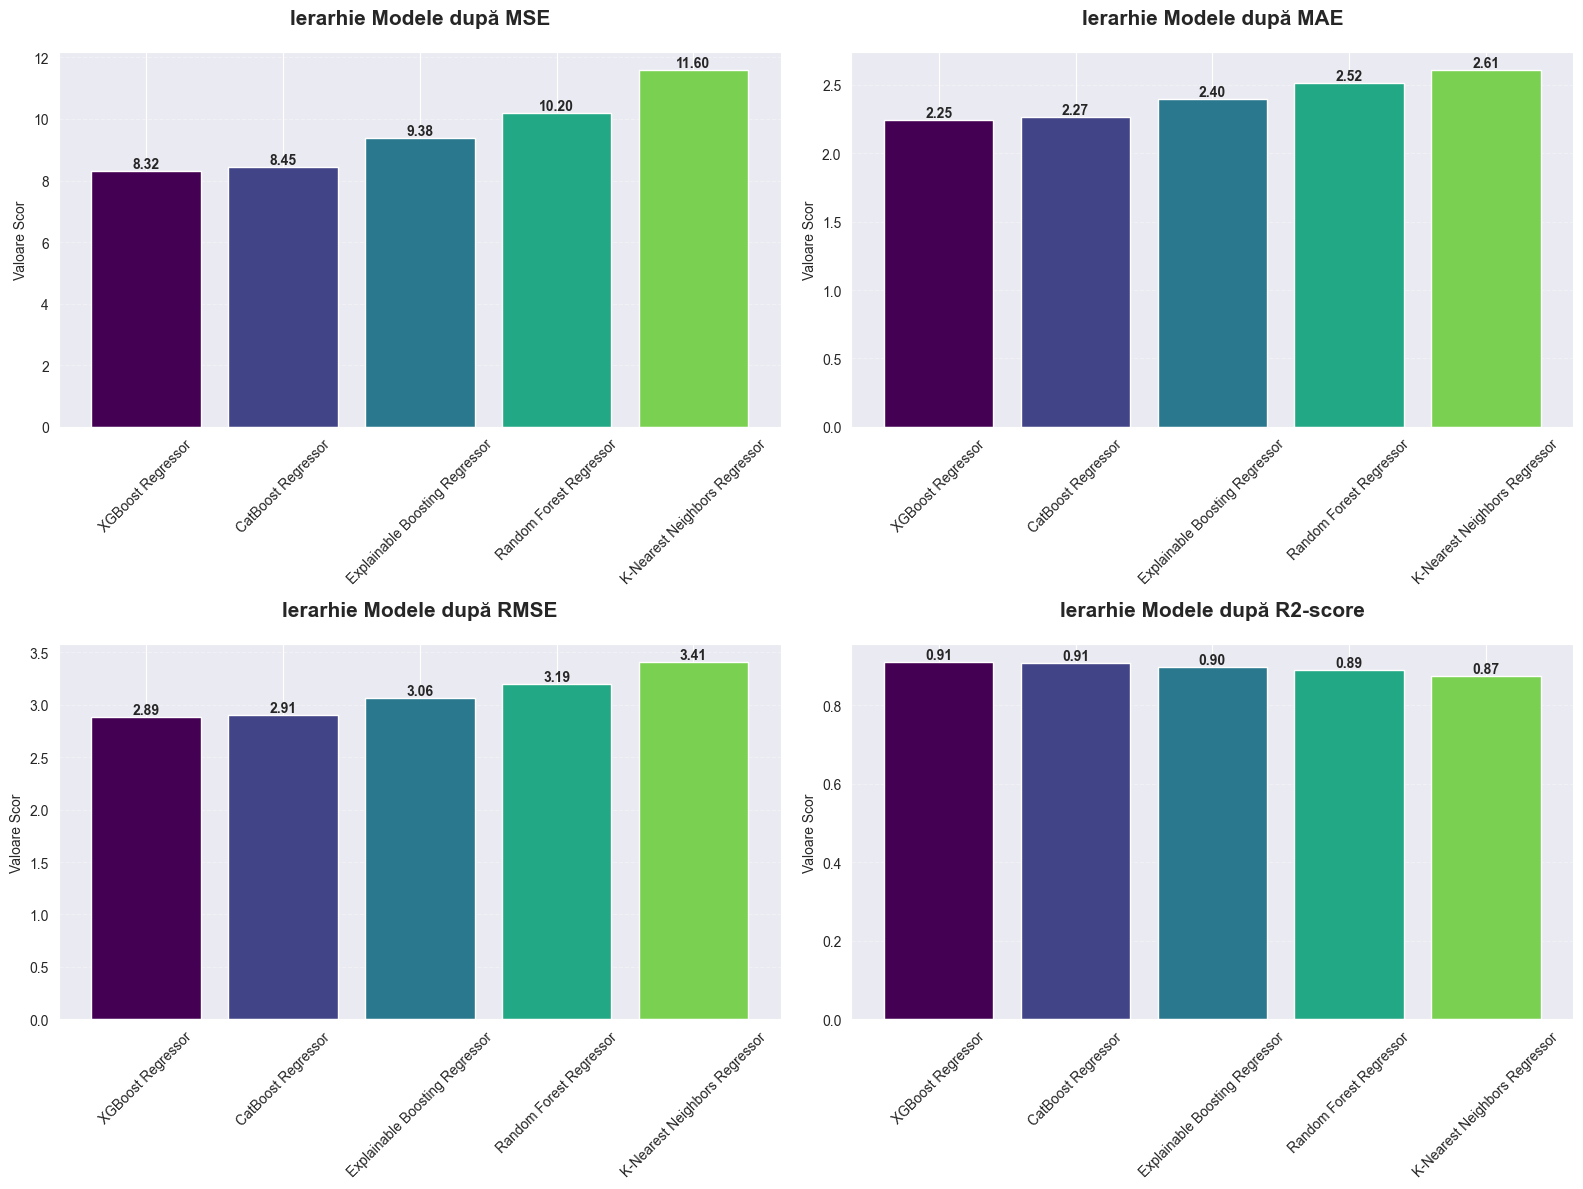

In [125]:
import matplotlib.pyplot as plt
import numpy as np

metric_names = ['MSE', 'MAE', 'RMSE', 'R2-score']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

nume_modele = opt_model['Model']

for i, metric in enumerate(metric_names):
    scoruri_metrica = opt_model[metric]

    data = list(zip(nume_modele, scoruri_metrica))
    if metric == 'R2-score':
        data.sort(key=lambda x: x[1], reverse=True)
    else:
        data.sort(key=lambda x: x[1]) # restu la fel , r2 e diferit, cu cat mai mare mai bun e, eroarea invers
    models, values = zip(*data)
    color_map = plt.cm.viridis(np.linspace(0, 0.8, len(models)))
    bars = axes[i].bar(models, values, color=color_map)

    axes[i].set_title(f'Ierarhie Modele după {metric}', fontsize=15, fontweight='bold', pad=20)
    axes[i].set_ylabel('Valoare Scor')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)
    for bar in bars:
        yval = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [126]:
df_opt_model['Score'] = 0
df_opt_model = df_opt_model.sort_values(by='MSE',ascending=True)
df_opt_model.loc[df_opt_model.index[:3],'Score'] += [3,2,1]

df_opt_model = df_opt_model.sort_values(by='MAE',ascending=True)
df_opt_model.loc[df_opt_model.index[:3],'Score'] += [3,2,1]

df_opt_model = df_opt_model.sort_values(by='RMSE',ascending=True)
df_opt_model.loc[df_opt_model.index[:3],'Score'] += [3,2,1]

df_opt_model = df_opt_model.sort_values(by='R2-score',ascending=False)
df_opt_model.loc[df_opt_model.index[:3],'Score'] += [3,2,1]

df_opt_model

,Model,MSE,MAE,RMSE,R2-score,Score
1,XGBoost Regressor,8.324923,2.245950,2.885294,0.910002,12
2,CatBoost Regressor,8.445364,2.268409,2.906091,0.908700,8
0,Explainable Boosting Regressor,9.384113,2.397774,3.063350,0.898552,4
3,Random Forest Regressor,10.198263,2.517619,3.193472,0.889750,0
4,K-Nearest Neighbors Regressor,11.602487,2.612219,3.406242,0.874570,0


In [127]:
df_opt_model.to_csv("../Datasets/Scores.csv",index=False)

In [105]:
df_opt_model.head(3)

,Model,MSE,MAE,RMSE,R2-score,Score
1,XGBoost Regressor,8.324923,2.245950,2.885294,0.910002,12
2,CatBoost Regressor,8.445364,2.268409,2.906091,0.908700,8
0,Explainable Boosting Regressor,9.384113,2.397774,3.063350,0.898552,4


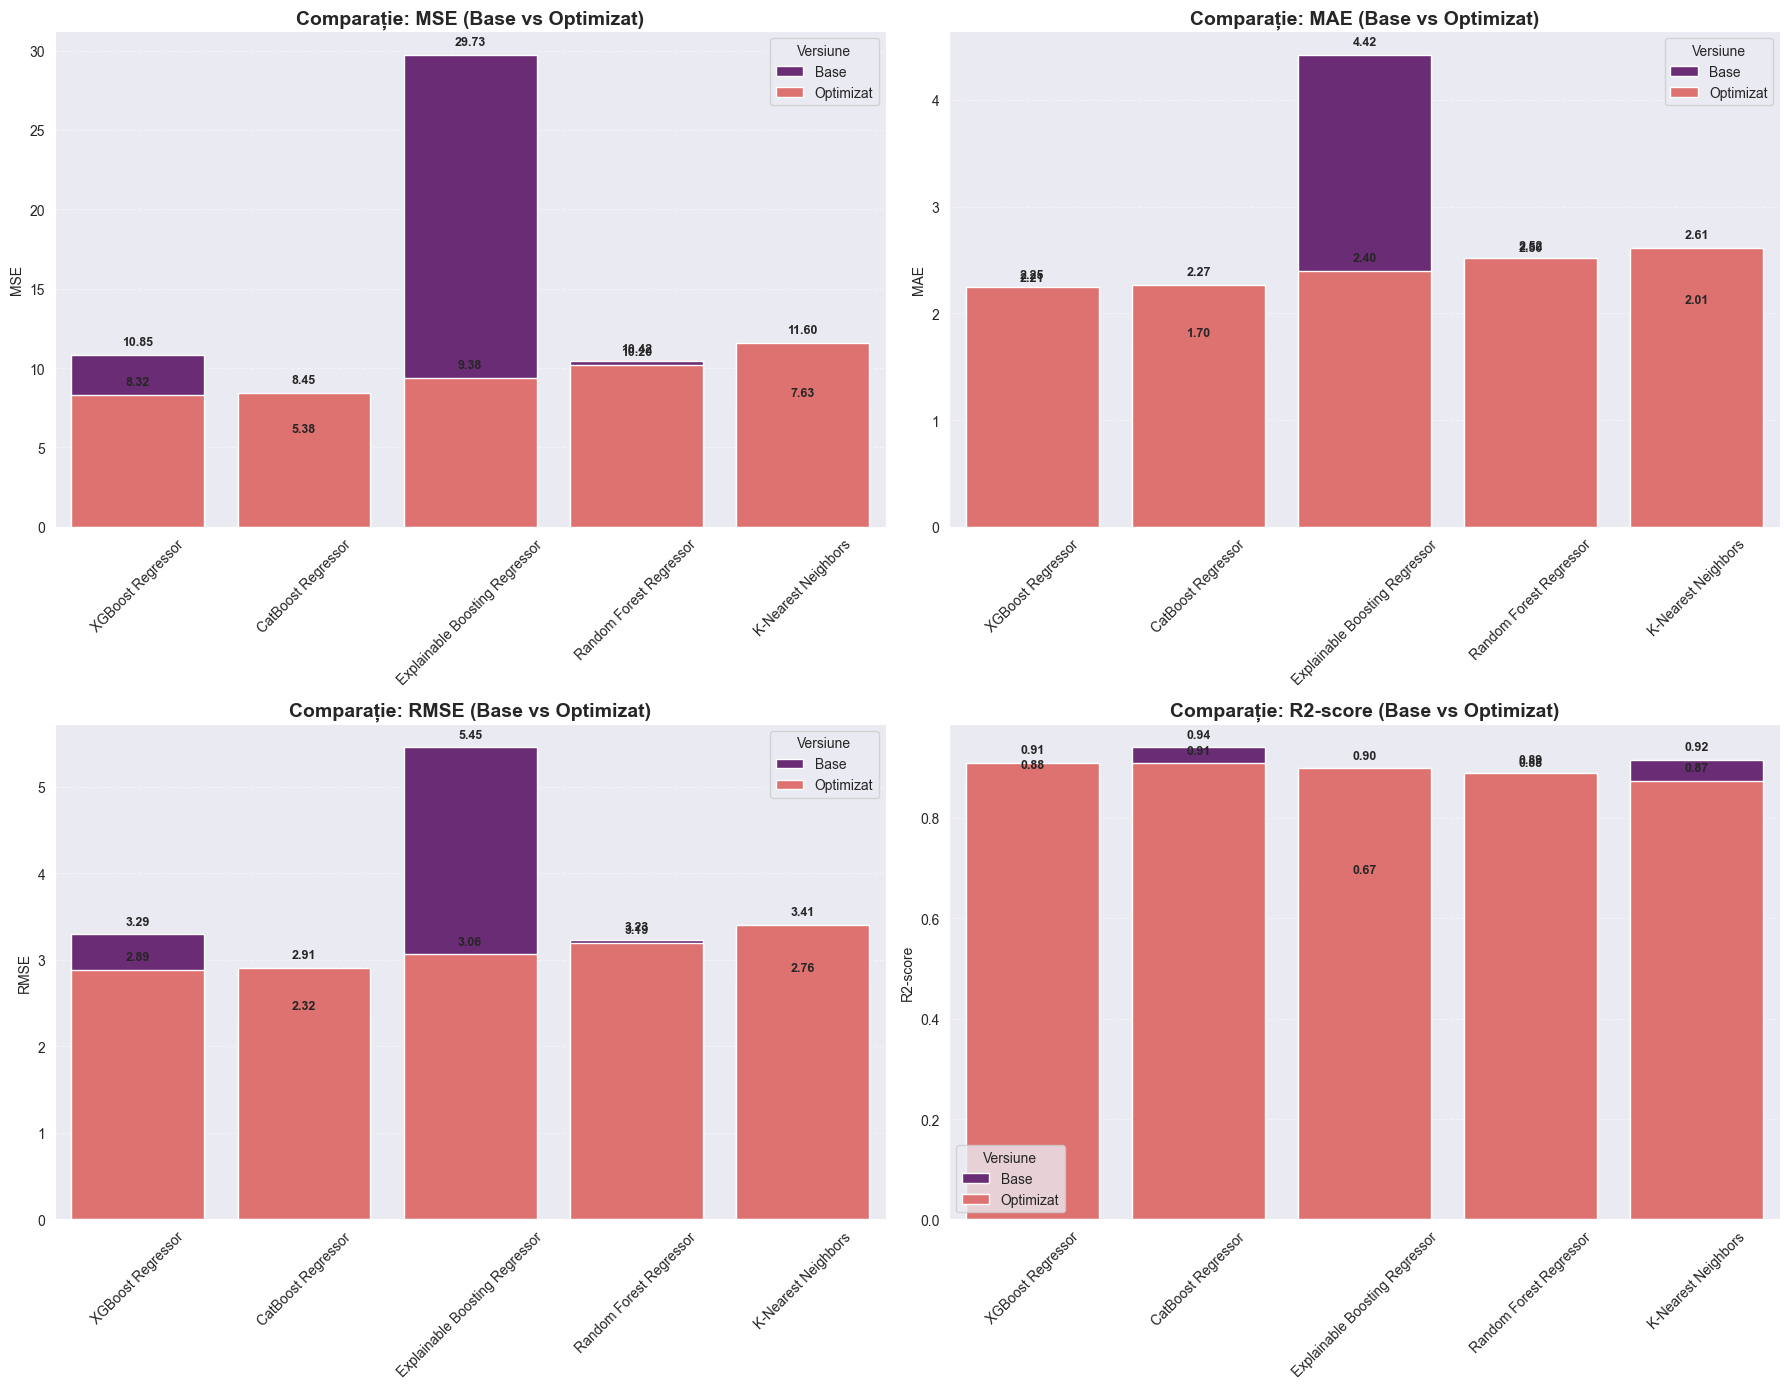

In [106]:
df_base = pd.DataFrame(model_base_grid)
df_base['Versiune'] = 'Base'

df_opt = pd.DataFrame(opt_model)
df_opt['Versiune'] = 'Optimizat'

df_comparativ = pd.concat([df_base, df_opt], axis=0)

metric_names = ['MSE', 'MAE', 'RMSE', 'R2-score']
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, metric in enumerate(metric_names):
    ascending_order = True if metric != 'R2-score' else False

    order = df_opt.sort_values(by=metric, ascending=ascending_order)['Model'].values

    sns.barplot(
        data=df_comparativ,
        x='Model',
        y=metric,
        hue='Versiune',
        ax=axes[i],
        palette='magma',
        order=order
    )

    axes[i].set_title(f'Comparație: {metric} (Base vs Optimizat)', fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

    for p in axes[i].patches:
        if p.get_height() > 0:
            axes[i].annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [109]:
df_comparativ['Score'] = 0
score_col_idx = df_comparativ.columns.get_loc('Score')

metrics = {
    'MSE': True,
    'MAE': True,
    'RMSE': True,
    'R2-score': False
}
for metric, is_ascending in metrics.items():
    df_comparativ = df_comparativ.sort_values(by=metric, ascending=is_ascending)
    df_comparativ.iloc[0, score_col_idx] += 3
    df_comparativ.iloc[1, score_col_idx] += 2
    df_comparativ.iloc[2, score_col_idx] += 1

df_final = df_comparativ.sort_values(by='Score', ascending=False).reset_index(drop=True)

print("Top Modele conform sistemului de punctaj:")
display(df_final[['Model', 'Versiune', 'MSE', 'R2-score', 'Score']].round(4))

Top Modele conform sistemului de punctaj:


,Model,Versiune,MSE,R2-score,Score
0,Random Forest,Base,5.3812,0.9405,12
1,XGBoost,Base,6.8793,0.9240,7
2,CatBoost,Base,6.9969,0.9227,3
3,KNN,Base,7.6256,0.9157,2
4,EBM,Base,7.7125,0.9147,0
5,XGBoost Regressor,Optimizat,8.3249,0.9100,0
6,CatBoost Regressor,Optimizat,8.4454,0.9087,0
7,Explainable Boosting Regressor,Optimizat,9.3841,0.8986,0
8,Random Forest Regressor,Optimizat,10.1983,0.8898,0
9,SVR,Base,10.4241,0.8848,0


Putem observa ca cele mai bune modele sunt cele default, deoarece probabil in spate, clasele stiu cum sa aleaga cei mai buni parametrii in scurt timp. Probabil daca lasam cautarea parametrilor mai mult, ajungeam la rezultate asemanatoare sau chiar putin mai bune.
Totusi, probabil pentru 0.03 score in plus ca coeficientul de determinare si o eroare putin mai mica, timpul asteptat tot nu merita.

### Explicabilitatea și analiza SHAP

#### 1.Random Forest - SHAP
Ca si explainer vom folosi un _Tree Explainer_, fiind mai performant.


In [99]:
import shap
background_size =min(30, len(X_train_scaled))
rf_ml.fit(X_train_scaled, y_train)
background = pd.DataFrame(X_train_scaled).sample(background_size, random_state=10)
explainer = shap.TreeExplainer(rf_ml)

In [100]:
sample_size =min(50, len(X_test_scaled))
X_shap_sample = X_test_scaled[:sample_size].copy()

shap_values =explainer.shap_values(X_shap_sample)
expected_values =explainer.expected_value

print("Numar exemple explicate:", len(X_shap_sample))
print("Tip obiect shap_values:", type(shap_values))

Numar exemple explicate: 50
Tip obiect shap_values: <class 'numpy.ndarray'>


Interpretare globala:

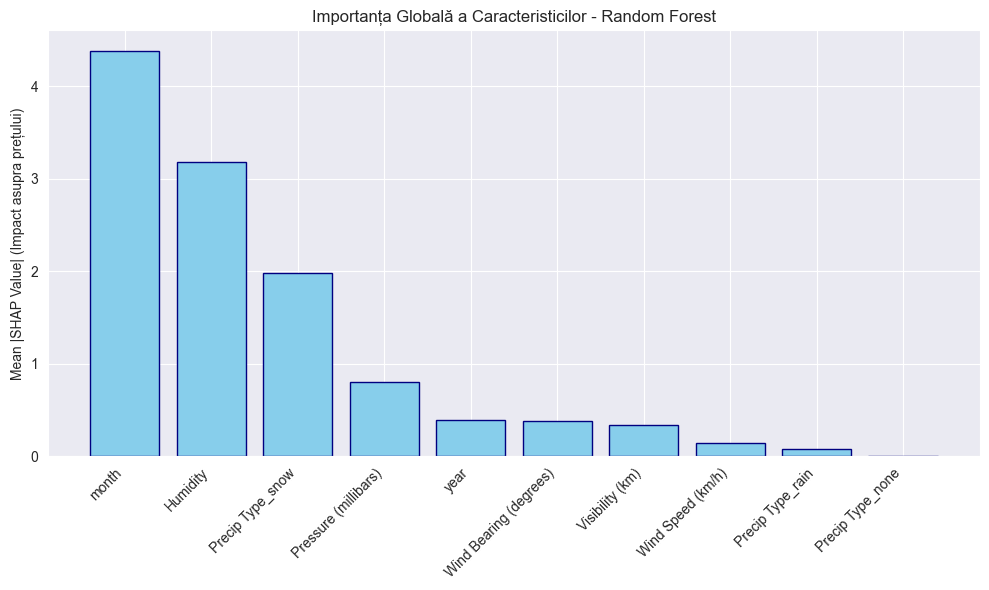

In [104]:
global_importance = np.mean(np.abs(shap_values), axis=0)
feature_cols = X.columns.tolist()
global_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": global_importance
}).sort_values(by="mean_abs_shap", ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(global_importance_df["feature"], global_importance_df["mean_abs_shap"], color='skyblue', edgecolor='navy')
plt.xticks(rotation=45, ha="right")
plt.ylabel("SHAP Value")
plt.title("Importanța Globală a Caracteristicilor - Random Forest")
plt.tight_layout()
plt.show()


Putem observa faptul ca cea mai mare influenta asupra prezicerii temperaturii o are luna, mai precis, probabil, in ce anotimp ne aflam. In plus, asa cum am observat din analiza exploratorie a datelor, este de asemenea si umiditatea si mai este important daca precipitatie este de tipul zapada sau nu, probabil atunci temperaturiile sunt scazute.
In plus, daca masuratorile s-ar intinde si pe mai multi ani, atunci ar creste importanta acestui atribut.

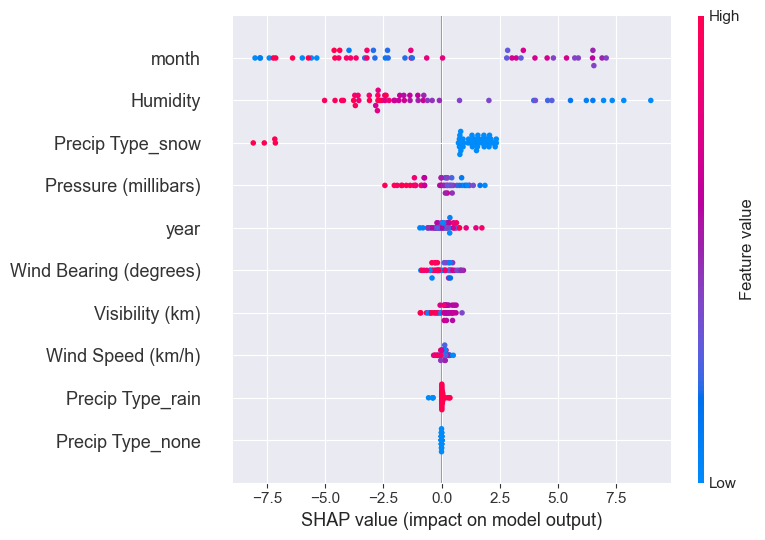

In [108]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=feature_cols,
    show=False
)
plt.tight_layout()
plt.show()

Putem observa faptul ca umiditatea are un impact pozitiv asupra shap value=ului, dar cu valoare putina. In plus, umiditatea si luna au o distributie mai mare si in impact mai mare asupra valorii shap.

#### Explicație locală
Aceasta analiza ne arata cum se comporta modelul in cadrul unei predictii a unei valori continue:

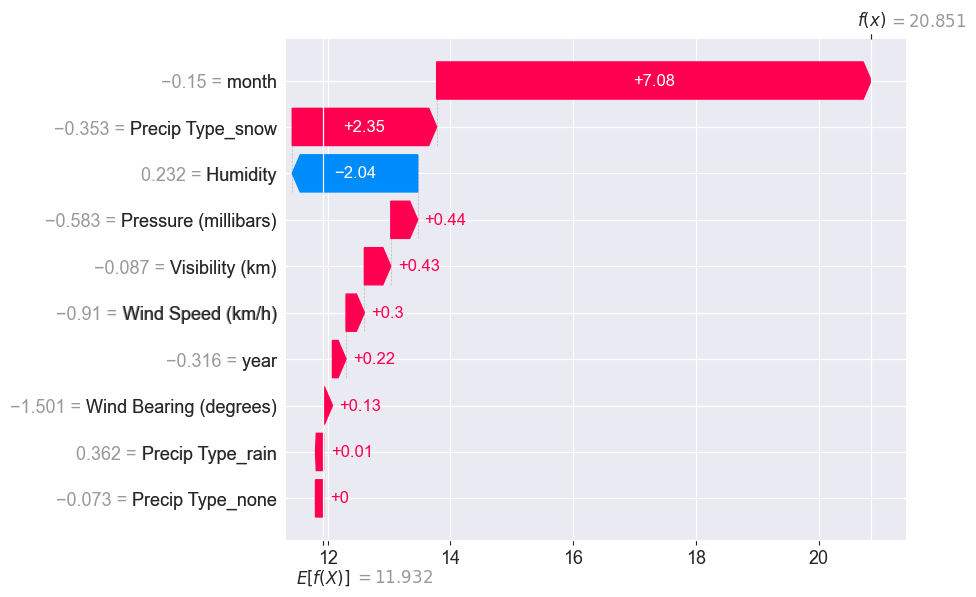

In [110]:
X_df = pd.DataFrame(X_shap_sample, columns=X_train.columns)
explanation_obj = explainer(X_df)
shap.plots.waterfall(explanation_obj[0])

Putem observa faptul ca faloarea de baza este de aproximativ 12.0 .  In plus, suma tuturor influentelor pozitive este de aproximativ 20. In plus, putem observa faptul ca umiditatea este singura are influenteaza overall rezultatul in jos.

In [111]:
shap.initjs()
shap.plots.force(explanation_obj[0])

In plus, putem observa ca se pastreaza consistenta si influenta coloanelor.

#### Scatter plot
O sa facem scatter plot pentru urmatoarele features:
- umiditate
- luna
- precipitatia ca zapada

Altfel spus, dorim sa vedem cu adevarat valorile acestor atribute si cat de mult influenteaza individual.

Scatter plot pentru umiditate:

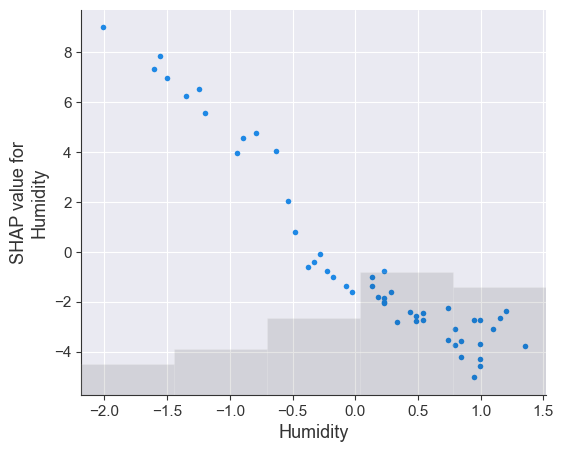

In [115]:
shap.plots.scatter(explanation_obj[:, "Humidity"])

Se observa o relatie aproximativ liniara, invers proportioanal cu umiditatea. Altfel spus, cu cat umiditatea din aer creste, cu atata valoarea shap este trasa in jos.

Scatter plot pentru luna:

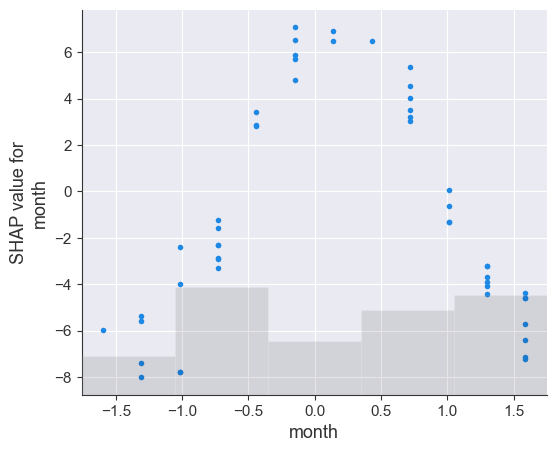

In [116]:
shap.plots.scatter(explanation_obj[:, "month"])

Se poate observa ca forma graficului este dupa clopotul lui Gauss, cu varful intre 0 si 0.5 . Asta este oarecum de asteptat, deoarece la mijlocul anului este cea mai calda vreme din an.

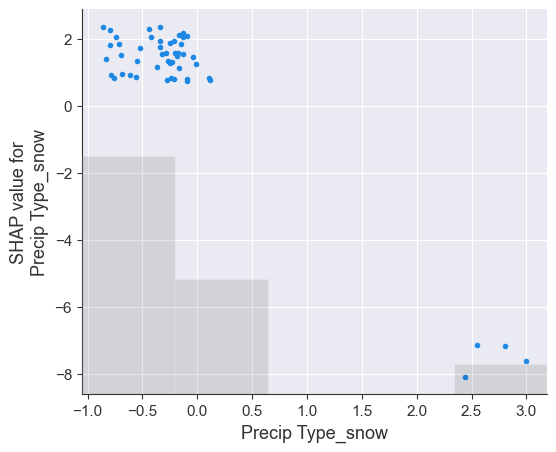

In [117]:
shap.plots.scatter(explanation_obj[:, "Precip Type_snow"])

Se observa cum impactul zapezii asupra valorii shap este in mare parte pozitiv, impingand in sus rezultatul.

#### 2.XGBoost - SHAP
Ca si explainer vom folosi un _Tree Explainer_, fiind mai performant.


In [118]:
import shap
background_size =min(30, len(X_train_scaled))
xgb_ml.fit(X_train_scaled, y_train)
explainer = shap.TreeExplainer(xgb_ml)

In [119]:
sample_size =min(500, len(X_test_scaled))
X_shap_sample = X_test_scaled[:sample_size].copy()

shap_values =explainer.shap_values(X_shap_sample)
expected_values =explainer.expected_value

print("Numar exemple explicate:", len(X_shap_sample))
print("Tip obiect shap_values:", type(shap_values))

Numar exemple explicate: 500
Tip obiect shap_values: <class 'numpy.ndarray'>


Interpretare globala:

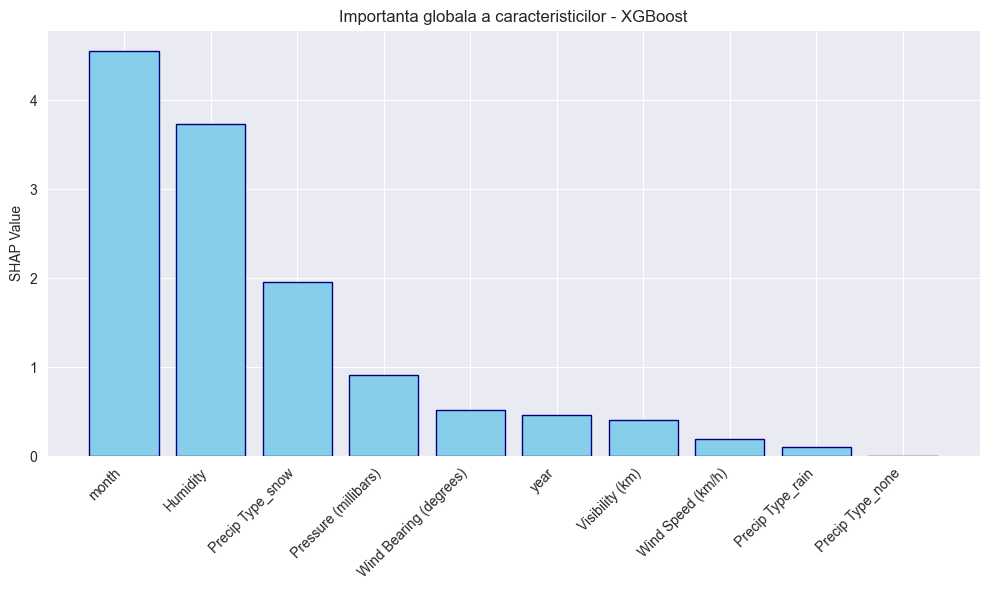

In [123]:
global_importance = np.mean(np.abs(shap_values), axis=0)
feature_cols = X.columns.tolist()
global_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": global_importance
}).sort_values(by="mean_abs_shap", ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(global_importance_df["feature"], global_importance_df["mean_abs_shap"], color='skyblue', edgecolor='navy')
plt.xticks(rotation=45, ha="right")
plt.ylabel("SHAP Value")
plt.title("Importanta globala a caracteristicilor - XGBoost")
plt.tight_layout()
plt.show()


Aceleasi date sunt ca si importanta vitale pentru modelul nostru.

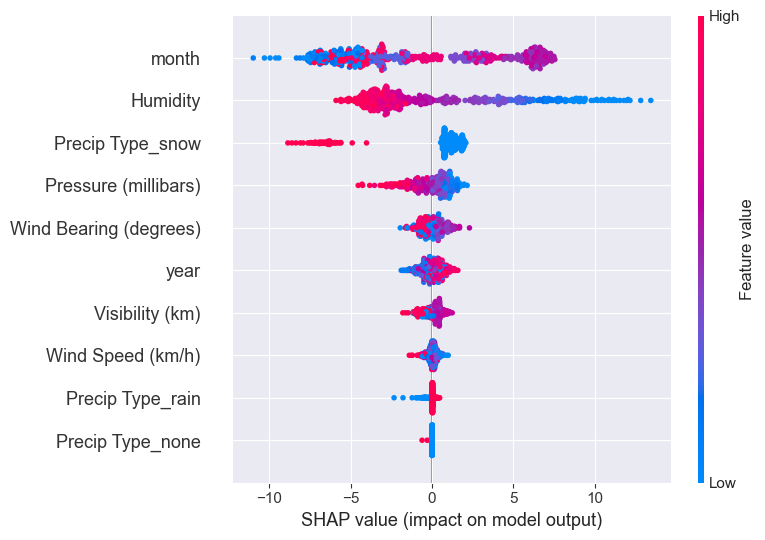

In [124]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=feature_cols,
    show=False
)
plt.tight_layout()
plt.show()

Umiditatea are o valoare mare in partea negativa si una mica in partea pozitiva, deci trage in jos valoarea shap. In plus, luna are o importanta mare pozitiva si impinge in sus valoarea.

#### Explicație locală
Aceasta analiza ne arata cum se comporta modelul in cadrul unei predictii a unei valori continue:

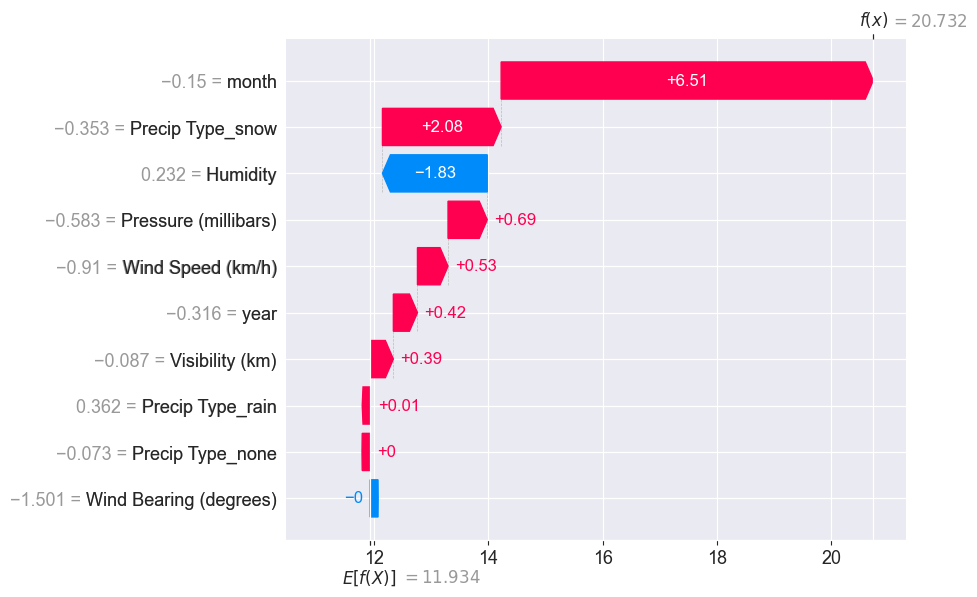

In [125]:
X_df = pd.DataFrame(X_shap_sample, columns=X_train.columns)
explanation_obj = explainer(X_df)
shap.plots.waterfall(explanation_obj[0])

Putem observa ca pe langa umiditatea, pe care o cunosteam de la modelul anterior ca trage in jos valoarea shap, mai este si vantul. Totusi, la acest model, impactul tuturor feature-lor este mai mic.

In [126]:
shap.initjs()
shap.plots.force(explanation_obj[0])

Valoarea de baza si totala este asemanatoare cu modelul anterior.

#### Scatter plot
O sa facem scatter plot pentru urmatoarele features:
- umiditate
- luna
- precipitatia ca zapada

Altfel spus, dorim sa vedem cu adevarat valorile acestor atribute si cat de mult influenteaza individual.

Scatter plot pentru umiditate:

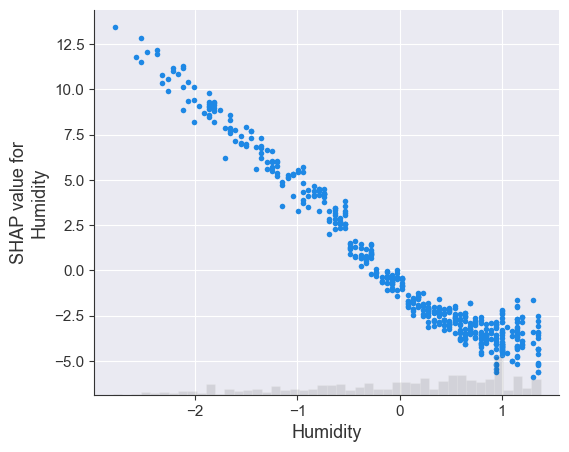

In [127]:
shap.plots.scatter(explanation_obj[:, "Humidity"])

In cazul acestui model, observam o relatie si mai liniara, invers proportionala cu umiditatea.

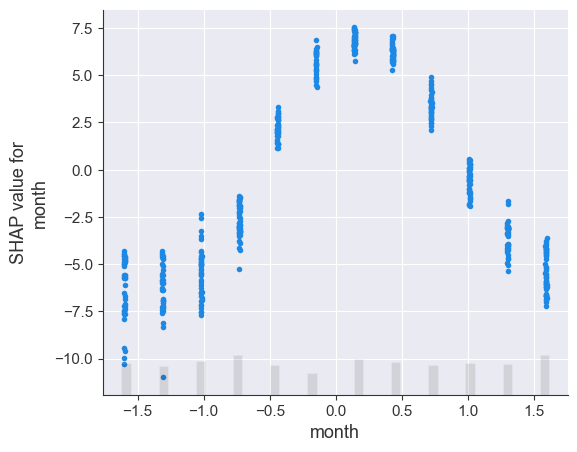

In [128]:
shap.plots.scatter(explanation_obj[:, "month"])

Tot clopotul lui gauss formeaza aceasta masuratoare, iar cele mai multe masuratori au avut loc la inceputul si sfarsitul anului

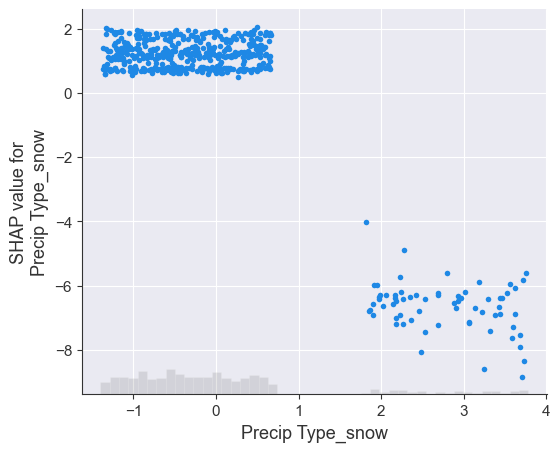

In [129]:
shap.plots.scatter(explanation_obj[:, "Precip Type_snow"])

Fulguirea impinge in sus valoarea shap.

#### 3.CatBoost - SHAP
Ca si explainer vom folosi un _Tree Explainer_, fiind mai performant.


In [131]:
import shap
background_size =min(30, len(X_train_scaled))
cat_ml.fit(X_train_scaled, y_train)
explainer = shap.TreeExplainer(xgb_ml)

Interpretare globala:

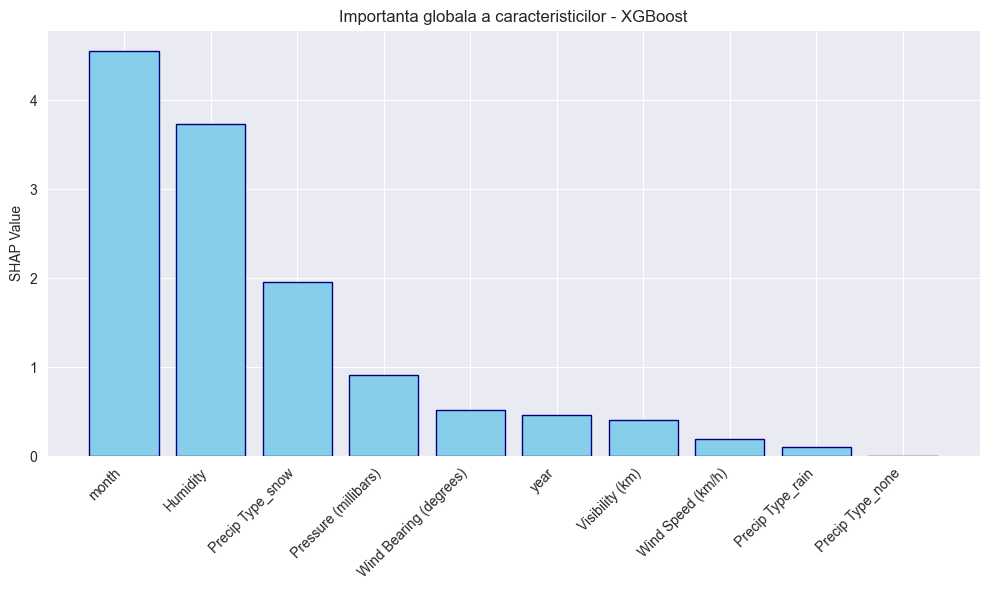

In [132]:
global_importance = np.mean(np.abs(shap_values), axis=0)
feature_cols = X.columns.tolist()
global_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": global_importance
}).sort_values(by="mean_abs_shap", ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(global_importance_df["feature"], global_importance_df["mean_abs_shap"], color='skyblue', edgecolor='navy')
plt.xticks(rotation=45, ha="right")
plt.ylabel("SHAP Value")
plt.title("Importanta globala a caracteristicilor - XGBoost")
plt.tight_layout()
plt.show()


Aceleasi 3 cele mai importante coloane, features.

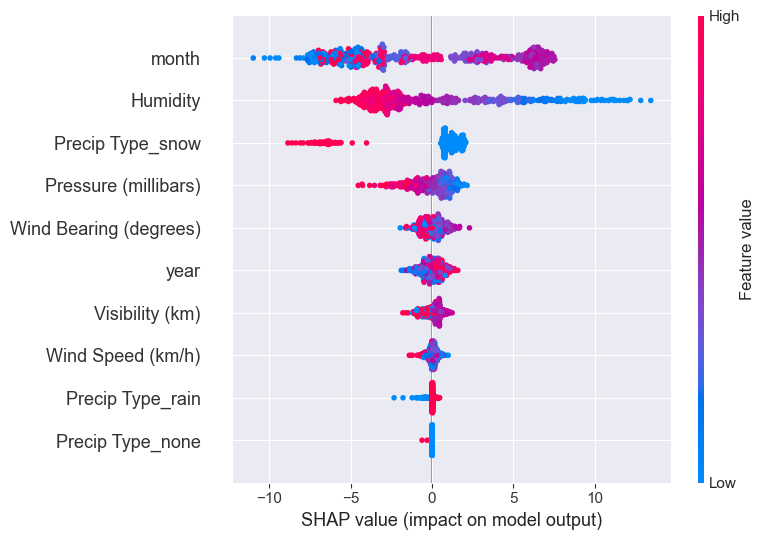

In [133]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=feature_cols,
    show=False
)
plt.tight_layout()
plt.show()

#### Explicație locală
Aceasta analiza ne arata cum se comporta modelul in cadrul unei predictii a unei valori continue:

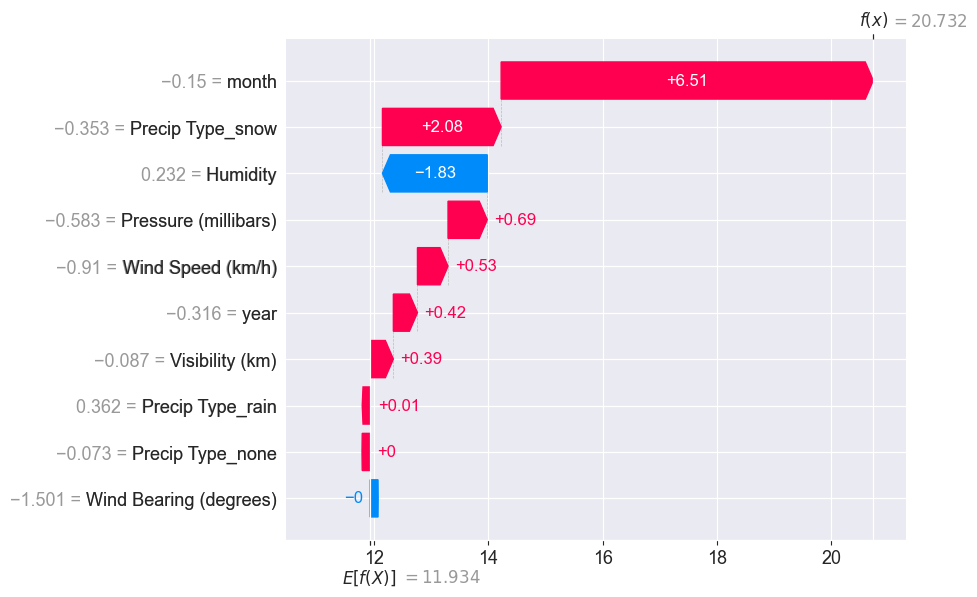

In [134]:
X_df = pd.DataFrame(X_shap_sample, columns=X_train.columns)
explanation_obj = explainer(X_df)
shap.plots.waterfall(explanation_obj[0])

In [135]:
shap.initjs()
shap.plots.force(explanation_obj[0])

#### Scatter plot
O sa facem scatter plot pentru urmatoarele features:
- umiditate
- luna
- precipitatia ca zapada

Altfel spus, dorim sa vedem cu adevarat valorile acestor atribute si cat de mult influenteaza individual.

Scatter plot pentru umiditate:

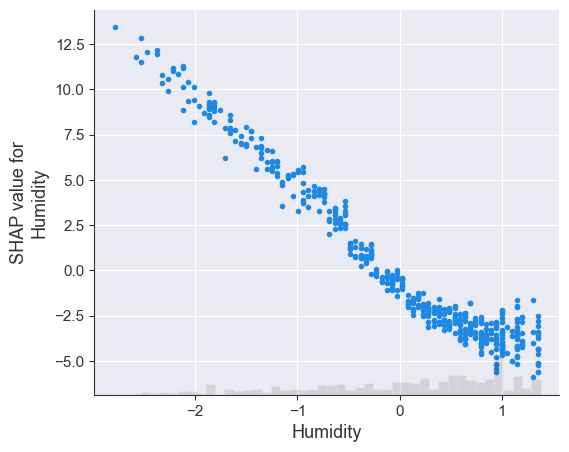

In [136]:
shap.plots.scatter(explanation_obj[:, "Humidity"])

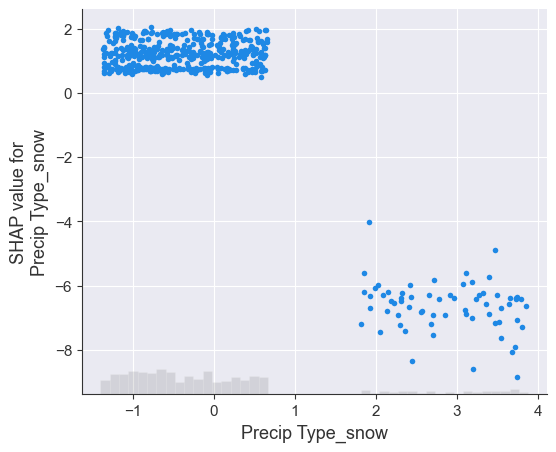

In [137]:
shap.plots.scatter(explanation_obj[:, "Precip Type_snow"])

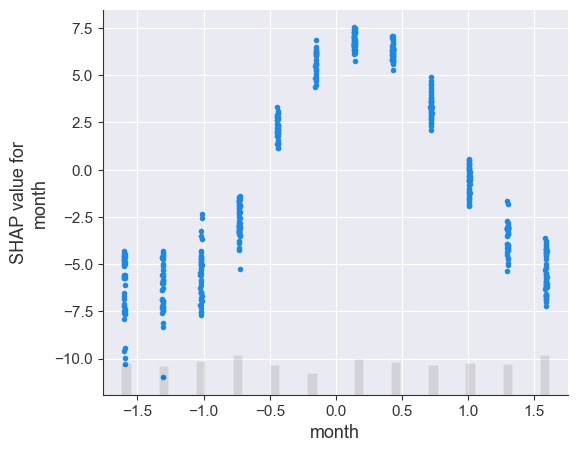

In [138]:
shap.plots.scatter(explanation_obj[:, "month"])

### Concluzie
#### Cele mai bune predictii conform analizei shap sunt :
- Month, care trage in sus valoarea shap.
- Precip Type_snow, care trage in sus valoarea shap.
- Humidity, care trage in jos valoarea shap.

De exemplu, daca dorim sa prezicem temperatura intr-o zi din iarna. Luna ne ajuta cel mai mult, deoarece modelul va compara cu restul experimentelor din acea perioada. Nu este obligatoriu sa ninga, dar daca o va face, mari sanse sa nu dea gres, iar umiditatea din aer depinde, iarne este cam mica, dar tot ajuta la conturarea valorii finale shap.